In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 1. 데이터 불러오기

In [ ]:
# =========================================================
# 0. 기본 설정
# =========================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기준
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "/content/drive/MyDrive/2026_기상청_축산"

files = {
    "train": "hanwoo_train.csv",
    "lineage": "hanwoo_lineage.csv",
    "weather": "hanwoo_weather.csv",
    "death": "hanwoo_death.csv",
    "area": "hanwoo_area.csv",
}

In [ ]:
# =========================================================
# 2. CSV 불러오기
#    - utf-8-sig 우선
#    - 실패하면 cp949/euc-kr 시도
# =========================================================

def read_csv_safe(path):
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]

    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False)
            print(f"[LOAD SUCCESS] {os.path.basename(path)} | encoding={enc} | shape={df.shape}")
            return df
        except UnicodeDecodeError:
            continue

    raise UnicodeDecodeError(f"인코딩 확인 필요: {path}")


dfs = {}

for name, fname in files.items():
    path = os.path.join(DATA_DIR, fname)
    dfs[name] = read_csv_safe(path)

train = dfs["train"]
lineage = dfs["lineage"]
weather = dfs["weather"]
death = dfs["death"]
area = dfs["area"]

[LOAD SUCCESS] hanwoo_train.csv | encoding=utf-8-sig | shape=(2408699, 23)
[LOAD SUCCESS] hanwoo_lineage.csv | encoding=utf-8-sig | shape=(1809455, 8)
[LOAD SUCCESS] hanwoo_weather.csv | encoding=utf-8-sig | shape=(973248, 7)
[LOAD SUCCESS] hanwoo_death.csv | encoding=utf-8-sig | shape=(321389, 4)
[LOAD SUCCESS] hanwoo_area.csv | encoding=utf-8-sig | shape=(91896, 5)


In [ ]:
# =========================================================
# 3. 전체 파일 구조 요약
# =========================================================

def basic_overview(df, name):
    print("=" * 80)
    print(f"[{name}]")
    print(f"shape: {df.shape}")
    print(f"memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("\n[columns]")
    print(df.columns.tolist())

    print("\n[dtypes]")
    display(df.dtypes.to_frame("dtype"))

    print("\n[head]")
    display(df.head())

    print("\n[tail]")
    display(df.tail())

    print("\n[duplicated rows]")
    print(df.duplicated().sum())

for name, df in dfs.items():
    basic_overview(df, name)

[train]
shape: (2408699, 23)
memory: 1787.73 MB

[columns]
['sido', 'sigungu', 'eupmyeondong', 'stn', 'ABATT_DATE', 'JUDGE_DATE', 'JUDGE_SEX', 'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'WGRADE', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT', 'AGE', 'BIRTH_YMD', 'CATTLE_NO', 'FARM_UNIQUE_NO', 'LAST_GRADE']

[dtypes]


,dtype
sido,object
sigungu,object
eupmyeondong,object
stn,int64
ABATT_DATE,object
JUDGE_DATE,object
JUDGE_SEX,object
WEIGHT,int64
BACKFAT,float64
REA,float64



[head]


,sido,sigungu,eupmyeondong,stn,ABATT_DATE,JUDGE_DATE,JUDGE_SEX,WEIGHT,BACKFAT,REA,WINDEX,WGRADE,INSFAT,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD,CATTLE_NO,FARM_UNIQUE_NO,LAST_GRADE
0,강원특별자치도,정선군,북평면,563,2023-01-01,2023-01-02,암,218,3.0000,44.0000,63.2300,A,1.0000,6.0000,7.0000,5.0000,9.0000,-99.0000,76,20160915,mI4i8G0BJ8kWD6gdm77RmTzyuIx6N2ZMaZ7wFXx3xb4=,hqh4Qmh5g+ymbYtqjAeKeA==,3B
1,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,520,12.0000,100.0000,61.4600,B,4.0000,5.0000,3.0000,3.0000,3.0000,-99.0000,32,20200504,tMgfi1p35taO9GH4XN4x0bfO8czy79B8V9NyczRuV+8=,N5qW6dZ91QWCMHg/1kPdlA==,1B
2,경상북도,영주시,이산면,837,2023-01-01,2023-01-02,거세,452,14.0000,104.0000,61.8600,B,9.0000,4.0000,3.0000,1.0000,3.0000,-99.0000,29,20200803,mdsSD4/sB06U68LNT6P/GUwei2ISyIBZ+R04iLw2mX0=,5UbtU8TgV2yu3Y4/jxuNMQ==,1++B
3,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,454,12.0000,95.0000,61.8300,B,9.0000,5.0000,3.0000,1.0000,3.0000,-99.0000,32,20200510,LZWd4YatUD851LyC/LFXuxPW7KEXTwVWQONOwqrkLPI=,N5qW6dZ91QWCMHg/1kPdlA==,1++B
4,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,462,10.0000,78.0000,61.2400,B,4.0000,5.0000,3.0000,3.0000,3.0000,-99.0000,32,20200511,A4FF/dhr8vg7JeW/eqc3922pA69nEaLL/+uoAusZqyU=,N5qW6dZ91QWCMHg/1kPdlA==,1B



[tail]


...


[head]


,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA
0,X8bGdfHedF2o5xSAAERtEA==,23.0000,26.0000,25.0000,220.0000
1,N9t4B2mc+EZsH7wBLT8U4Q==,37.0000,34.0000,32.0000,431.0500
2,DeEu4RIkIUXq7NyTBwD8vg==,10.0000,5.0000,3.0000,265.8200
3,fgQkQJ+iyrFZDHsC9ih9mQ==,35.0000,41.0000,40.0000,593.8000
4,2mUAsXfTviEJtFBM7s31uw==,16.0000,14.0000,15.0000,155.6100



[tail]


,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA
91891,gAy2LxRXyYVOsIBAwD11/A==,1.0000,-99.0000,-99.0000,-99.0000
91892,x5Z4n8XI4ayOEfs8ZmTqvQ==,-99.0000,39.0000,38.0000,-99.0000
91893,VRvRQClyH/as9CmpHnu9lw==,-99.0000,27.0000,26.0000,604.0000
91894,+YcOQaM5gnT582PtgW/zjg==,-99.0000,-99.0000,21.0000,"1,043.2000"
91895,Ufbu2gWgtqP+uxALj2L8XQ==,-99.0000,-99.0000,43.0000,-99.0000



[duplicated rows]
16


# 2. 결측치 처리

In [ ]:
# =========================================================
# 4. 결측치 / unique 개수 / 기본 통계 요약
# =========================================================

def check_missing_with_sentinel(df, name, sentinel_values=(-99, -99.0)):
    """
    일반 NaN 결측치와 -99 / -99.0 형태의 결측 코드를 함께 확인하는 함수
    """
    result = []

    for col in df.columns:
        s = df[col]

        # 일반 NaN
        n_na = s.isna().sum()

        # 숫자형 컬럼의 -99, -99.0 확인
        if pd.api.types.is_numeric_dtype(s):
            n_sentinel = s.isin(sentinel_values).sum()

        # 문자형 컬럼의 "-99", "-99.0", 공백 포함 형태 확인
        else:
            s_str = s.astype("string").str.strip()
            n_sentinel = s_str.str.fullmatch(r"-99(\.0+)?", na=False).sum()

        n_total_missing = n_na + n_sentinel

        result.append({
            "dataset": name,
            "column": col,
            "dtype": s.dtype,
            "n_rows": len(df),
            "n_na": n_na,
            "n_sentinel_-99": n_sentinel,
            "n_total_missing": n_total_missing,
            "missing_rate": n_total_missing / len(df)
        })

    result_df = pd.DataFrame(result)
    result_df = result_df.sort_values("missing_rate", ascending=False)

    return result_df

In [ ]:
missing_reports = {}

for name, df in dfs.items():
    print("=" * 80)
    print(f"[{name}] -99 포함 결측치 확인")

    missing_reports[name] = check_missing_with_sentinel(df, name)
    display(missing_reports[name])

[train] -99 포함 결측치 확인


,dataset,column,dtype,n_rows,n_na,n_sentinel_-99,n_total_missing,missing_rate
17,train,COST_AMT,float64,2408699,0,885003,885003,0.3674
12,train,INSFAT,float64,2408699,0,5331,5331,0.0022
15,train,TISSUE,float64,2408699,0,5320,5320,0.0022
13,train,YUKSAK,float64,2408699,0,5269,5269,0.0022
10,train,WINDEX,float64,2408699,0,5252,5252,0.0022
9,train,REA,float64,2408699,0,5188,5188,0.0022
11,train,WGRADE,object,2408699,0,4814,4814,0.0020
14,train,FATSAK,float64,2408699,0,4743,4743,0.0020
8,train,BACKFAT,float64,2408699,0,4567,4567,0.0019
16,train,GROWTH,float64,2408699,0,9,9,0.0000


[lineage] -99 포함 결측치 확인


,dataset,column,dtype,n_rows,n_na,n_sentinel_-99,n_total_missing,missing_rate
1,lineage,KPN_NO,object,1809455,0,4490,4490,0.0025
0,lineage,CATTLE_NO,object,1809455,0,0,0,0.0000
2,lineage,FATHER_CATTLE_NO,object,1809455,0,0,0,0.0000
3,lineage,MOTHER_ANIMAL_NO,object,1809455,0,0,0,0.0000
4,lineage,F_GMOTHER_ANIMAL_NO,object,1809455,0,0,0,0.0000
5,lineage,F_GFATHER_CATTLE_NO,object,1809455,0,0,0,0.0000
6,lineage,M_GMOTHER_ANIMAL_NO,object,1809455,0,0,0,0.0000
7,lineage,M_GFATHER_CATTLE_NO,object,1809455,0,0,0,0.0000


[weather] -99 포함 결측치 확인


,dataset,column,dtype,n_rows,n_na,n_sentinel_-99,n_total_missing,missing_rate
5,weather,rhm_avg,float64,973248,0,48155,48155,0.0495
3,weather,rn_day,float64,973248,0,15993,15993,0.0164
6,weather,ws_davg,float64,973248,0,13602,13602,0.0140
2,weather,ta_max,float64,973248,0,12364,12364,0.0127
4,weather,ta_min,float64,973248,0,12364,12364,0.0127
1,weather,date,object,973248,0,0,0,0.0000
0,weather,stn,int64,973248,0,0,0,0.0000


[death] -99 포함 결측치 확인


,dataset,column,dtype,n_rows,n_na,n_sentinel_-99,n_total_missing,missing_rate
3,death,DEAD_REASON,object,321389,0,234276,234276,0.7289
0,death,FARM_UNIQUE_NO,object,321389,0,0,0,0.0000
1,death,BIRTH_YMD,int64,321389,0,0,0,0.0000
2,death,DEAD_YMD,int64,321389,0,0,0,0.0000


[area] -99 포함 결측치 확인


,dataset,column,dtype,n_rows,n_na,n_sentinel_-99,n_total_missing,missing_rate
4,area,AREA,float64,91896,0,29043,29043,0.3160
3,area,C2025,float64,91896,0,15613,15613,0.1699
2,area,C2024,float64,91896,0,10984,10984,0.1195
1,area,C2023,float64,91896,0,5196,5196,0.0565
0,area,FARM_UNIQUE_NO,object,91896,0,0,0,0.0000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 큰 데이터 시각화용 샘플
SAMPLE_N = 200_000

train_sample = train.sample(
    n=min(SAMPLE_N, len(train)),
    random_state=42
).copy()

In [ ]:
################
# 결측치 표준화 - -99, -99.0을 NaN으로 표준화
################
def replace_minus99_to_nan(df):
    df = df.copy()

    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].mask(df[col].isin([-99, -99.0]), np.nan)
        else:
            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .replace(r"^-99(\.0+)?$", np.nan, regex=True)
            )

    return df


train = replace_minus99_to_nan(train)
area = replace_minus99_to_nan(area)
death = replace_minus99_to_nan(death)
weather = replace_minus99_to_nan(weather)
lineage = replace_minus99_to_nan(lineage)

train_sample = train.sample(
    n=min(SAMPLE_N, len(train)),
    random_state=42
).copy()

dfs_clean에 결측치들이 NaN으로 들어가있게 저장해둠.

# 3. 초기 EDA 진행

In [ ]:
# Colab에서 한글 폰트 설치
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil
import os

# matplotlib font cache 삭제
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

# NanumGothic 직접 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

print("NanumGothic font setting complete.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
NanumGothic font setting complete.


In [ ]:
# 날짜형 변환 먼저

train["ABATT_DATE"] = pd.to_datetime(train["ABATT_DATE"], errors="coerce")
train["JUDGE_DATE"] = pd.to_datetime(train["JUDGE_DATE"], errors="coerce")
train["BIRTH_YMD"] = pd.to_datetime(
    train["BIRTH_YMD"].astype("string"),
    format="%Y%m%d",
    errors="coerce"
)

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

death["BIRTH_YMD"] = pd.to_datetime(
    death["BIRTH_YMD"].astype("string"),
    format="%Y%m%d",
    errors="coerce"
)
death["DEAD_YMD"] = pd.to_datetime(
    death["DEAD_YMD"].astype("string"),
    format="%Y%m%d",
    errors="coerce"
)

train["abatt_year"] = train["ABATT_DATE"].dt.year
train["abatt_month"] = train["ABATT_DATE"].dt.month

train_sample = train.sample(
    n=min(SAMPLE_N, len(train)),
    random_state=42
).copy()

## 3-1. train 단독 EDA

In [ ]:
# 타깃 분포 확인
train["LAST_GRADE"].value_counts(dropna=False)
train["LAST_GRADE"].value_counts(normalize=True, dropna=False)

,proportion
LAST_GRADE,
1++B,0.1327
1+B,0.1292
1B,0.1243
1++A,0.0859
2B,0.0813
1A,0.0698
1+A,0.0694
1+C,0.0540
1++C,0.0536


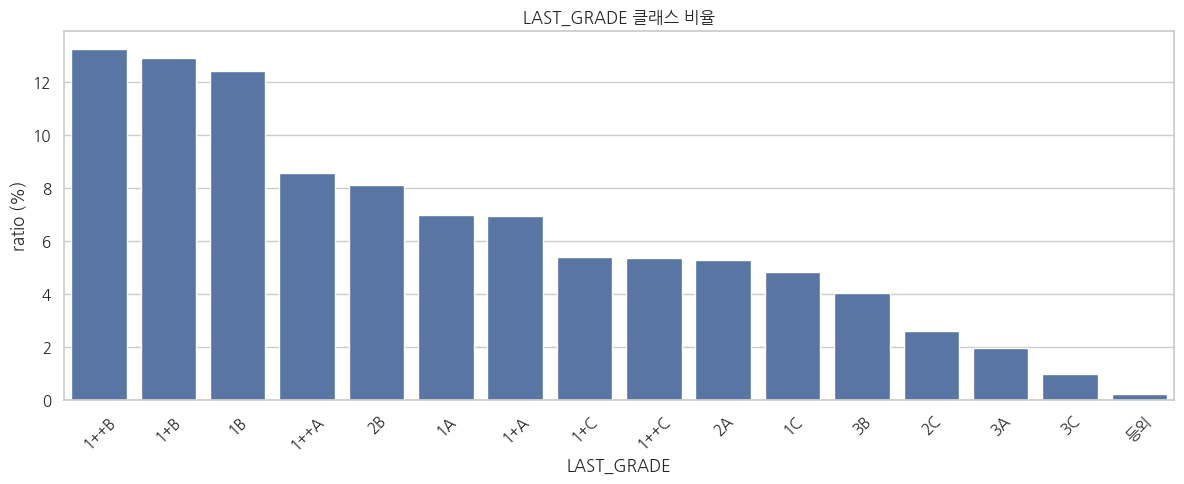

In [ ]:
plt.figure(figsize=(12, 5))

grade_ratio = train["LAST_GRADE"].value_counts(normalize=True, dropna=False) * 100

sns.barplot(
    x=grade_ratio.index.astype(str),
    y=grade_ratio.values
)

plt.title("LAST_GRADE 클래스 비율") # 클래스 비율
plt.xlabel("LAST_GRADE")
plt.ylabel("ratio (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

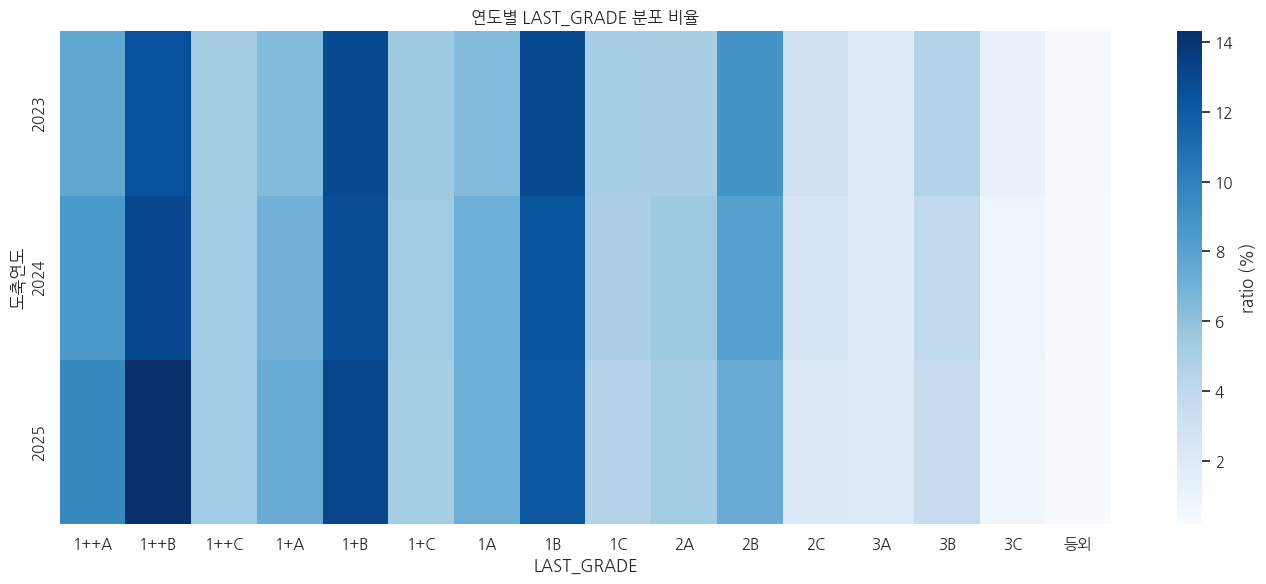

In [ ]:
grade_year = pd.crosstab(
    train["abatt_year"],
    train["LAST_GRADE"],
    normalize="index"
) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(
    grade_year,
    cmap="Blues",
    annot=False,
    cbar_kws={"label": "ratio (%)"}
)

plt.title("연도별 LAST_GRADE 분포 비율")
plt.xlabel("LAST_GRADE")
plt.ylabel("도축연도")
plt.tight_layout()
plt.show()

체크할 것
- 클래스 불균형
- 소수 등급 존재 여부
- 1++B, 1+B, 1B, 1++A, 2B 비중
- 등급을 그대로 다중분류로 둘지, 단순화할지

In [ ]:
# 성별 분석
train["JUDGE_SEX"].value_counts(dropna=False)

train.groupby("JUDGE_SEX")[["WEIGHT", "BACKFAT", "REA", "INSFAT", "AGE"]].describe()
pd.crosstab(train["JUDGE_SEX"], train["LAST_GRADE"], normalize="index")

LAST_GRADE,1++A,1++B,1++C,1+A,1+B,1+C,1A,1B,1C,2A,2B,2C,3A,3B,3C,등외
JUDGE_SEX,,,,,,,,,,,,,,,,
거세,0.1313,0.1946,0.0746,0.0855,0.1530,0.0602,0.0657,0.1095,0.0402,0.0298,0.0368,0.0102,0.0025,0.0049,0.0005,0.0006
수,0.0003,0.0008,0.0009,0.0010,0.0047,0.0018,0.0035,0.0157,0.0101,0.0432,0.1058,0.0354,0.3403,0.3601,0.0486,0.0277
암,0.0396,0.0696,0.0321,0.0534,0.1056,0.0481,0.0748,0.1407,0.0576,0.0770,0.1274,0.0426,0.0342,0.0744,0.0190,0.0038


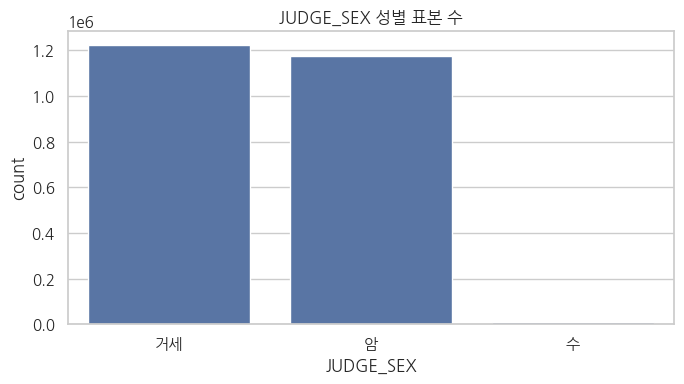

In [ ]:
plt.figure(figsize=(7, 4))

sex_counts = train["JUDGE_SEX"].value_counts(dropna=False)

sns.barplot(
    x=sex_counts.index.astype(str),
    y=sex_counts.values
)

plt.title("JUDGE_SEX 성별 표본 수")
plt.xlabel("JUDGE_SEX")
plt.ylabel("count")
plt.tight_layout()
plt.show()

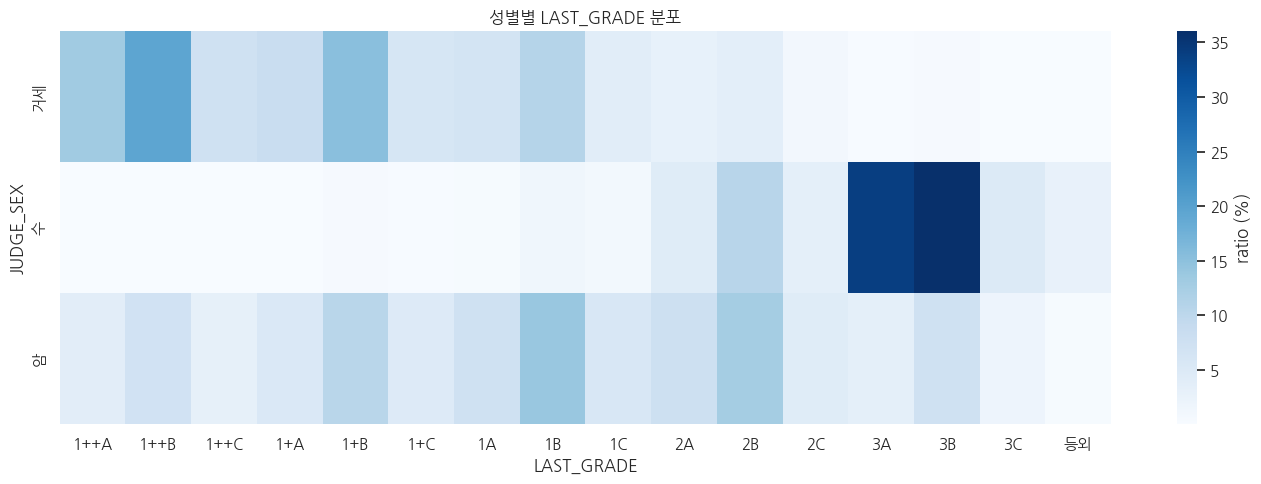

In [ ]:
sex_grade = pd.crosstab(
    train["JUDGE_SEX"],
    train["LAST_GRADE"],
    normalize="index"
) * 100

plt.figure(figsize=(14, 5))
sns.heatmap(
    sex_grade,
    cmap="Blues",
    annot=False,
    cbar_kws={"label": "ratio (%)"}
)

plt.title("성별별 LAST_GRADE 분포")
plt.xlabel("LAST_GRADE")
plt.ylabel("JUDGE_SEX")
plt.tight_layout()
plt.show()

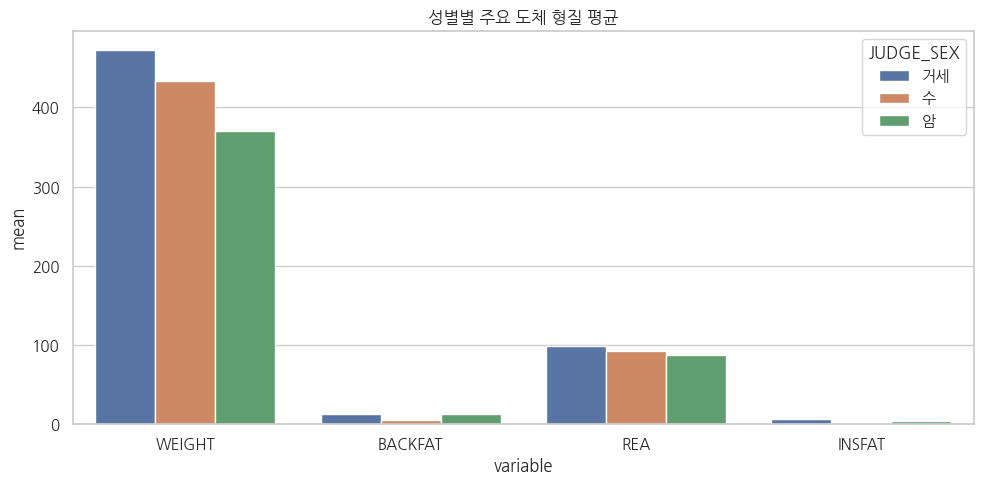

In [ ]:
sex_mean = (
    train
    .groupby("JUDGE_SEX")[["WEIGHT", "BACKFAT", "REA", "INSFAT"]]
    .mean()
    .reset_index()
    .melt(id_vars="JUDGE_SEX", var_name="variable", value_name="mean")
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=sex_mean,
    x="variable",
    y="mean",
    hue="JUDGE_SEX"
)

plt.title("성별별 주요 도체 형질 평균")
plt.xlabel("variable")
plt.ylabel("mean")
plt.tight_layout()
plt.show()

체크할 것
- 거세/암/수의 표본 수 차이
- 성별별 체중 차이
- 성별별 등지방 차이
- 성별별 등심면적 차이
- 성별별 LAST_GRADE 분포 차이

In [ ]:
# 연령 분석
train["AGE"].describe()
train["AGE"].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])

,AGE
0.0010,16.0000
0.0100,24.0000
0.0500,28.0000
0.5000,33.0000
0.9500,88.0000
0.9900,132.0000
0.9990,183.0000


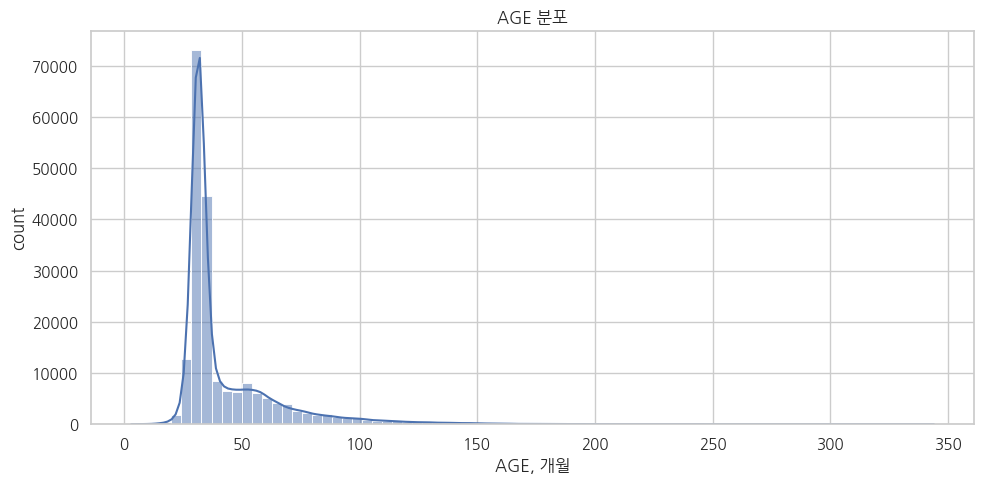

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_sample["AGE"].dropna(),
    bins=80,
    kde=True
)

plt.title("AGE 분포")
plt.xlabel("AGE, 개월")
plt.ylabel("count")
plt.tight_layout()
plt.show()

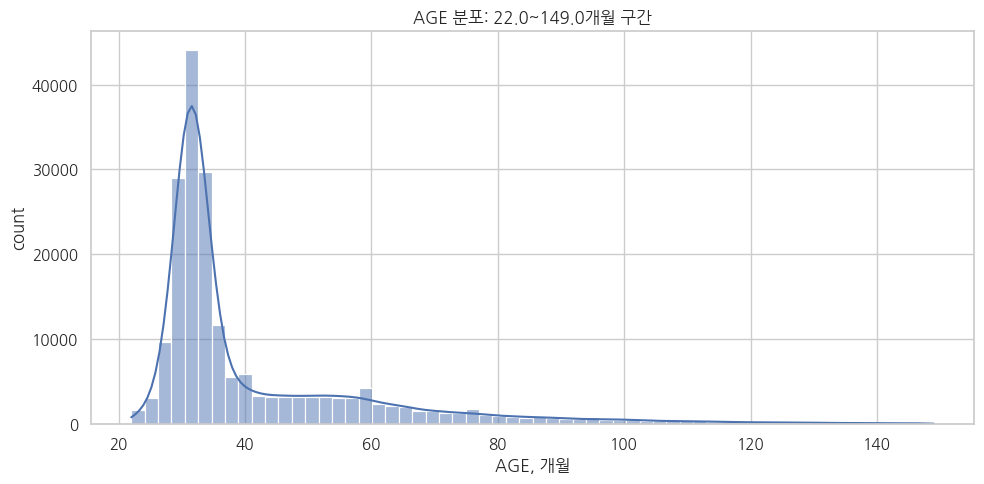

In [ ]:
age_low = train["AGE"].quantile(0.005)
age_high = train["AGE"].quantile(0.995)

age_filtered = train_sample[
    train_sample["AGE"].between(age_low, age_high)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    age_filtered["AGE"].dropna(),
    bins=60,
    kde=True
)

plt.title(f"AGE 분포: {age_low:.1f}~{age_high:.1f}개월 구간")
plt.xlabel("AGE, 개월")
plt.ylabel("count")
plt.tight_layout()
plt.show()
# AGE가 1~344개월까지 넓으므로, 먼저 중앙 구간을 따로 보는 게 좋을 듯 싶어서..

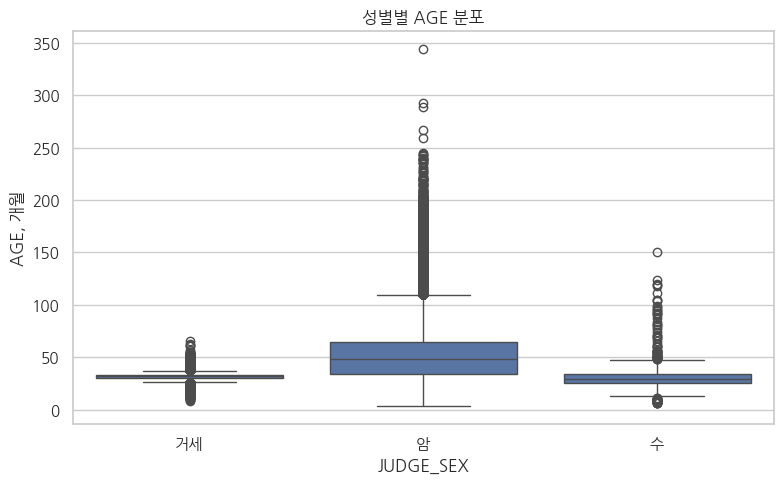

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train_sample,
    x="JUDGE_SEX",
    y="AGE"
)

plt.title("성별별 AGE 분포")
plt.xlabel("JUDGE_SEX")
plt.ylabel("AGE, 개월")
plt.tight_layout()
plt.show()

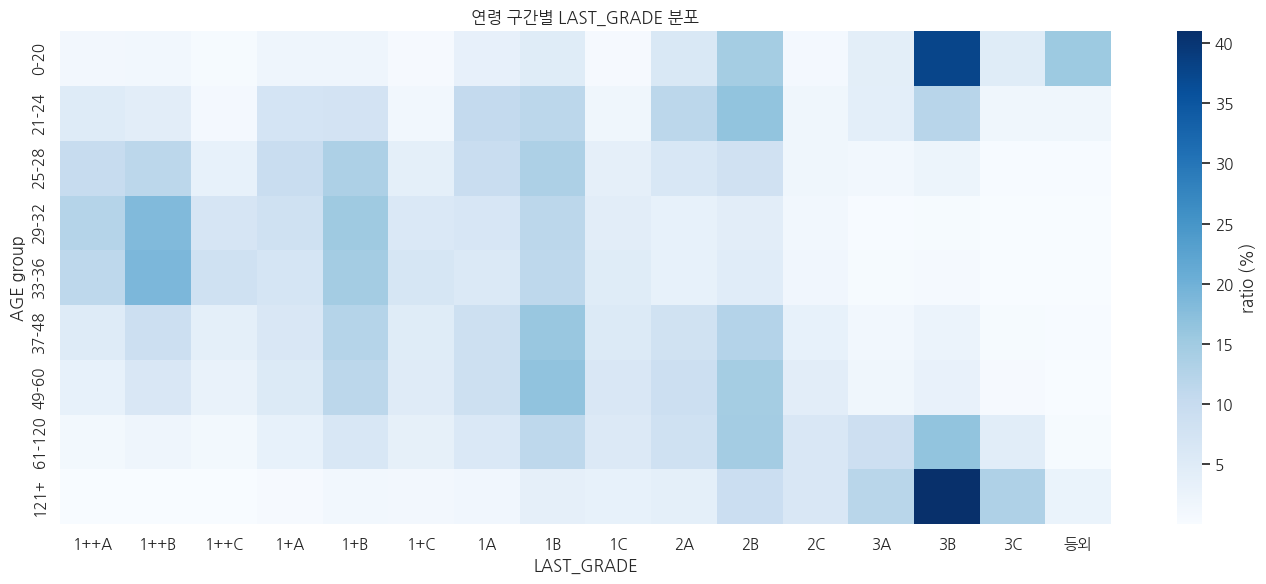

In [ ]:
age_bins = [0, 20, 24, 28, 32, 36, 48, 60, 120, 400]
age_labels = [
    "0-20", "21-24", "25-28", "29-32", "33-36",
    "37-48", "49-60", "61-120", "121+"
]

train["age_group"] = pd.cut(
    train["AGE"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

age_grade = pd.crosstab(
    train["age_group"],
    train["LAST_GRADE"],
    normalize="index"
) * 100

plt.figure(figsize=(14, 6))

sns.heatmap(
    age_grade,
    cmap="Blues",
    annot=False,
    cbar_kws={"label": "ratio (%)"}
)

plt.title("연령 구간별 LAST_GRADE 분포")
plt.xlabel("LAST_GRADE")
plt.ylabel("AGE group")
plt.tight_layout()
plt.show()

체크할 것
- AGE 1~344개월이 실제인지 오류인지
- 성별별 AGE 분포
- 등급별 AGE 분포
- 극단 연령에서 LAST_GRADE가 어떻게 분포하는지

In [ ]:
# 지역 분석
train["sido"].value_counts()
train["sigungu"].value_counts().head(30)
train["stn"].value_counts().head(30)

pd.crosstab(train["sido"], train["LAST_GRADE"], normalize="index")
train.groupby("sido")[["WEIGHT", "BACKFAT", "REA", "INSFAT", "AGE"]].mean()

,WEIGHT,BACKFAT,REA,INSFAT,AGE
sido,,,,,
강원특별자치도,418.2471,12.1155,92.8399,5.2938,42.8742
경기도,423.5735,11.9145,92.6514,5.3384,40.7705
경상남도,421.3410,12.8081,93.9637,5.2702,45.5534
경상북도,436.4409,12.9174,94.4992,5.5667,41.1757
광주광역시,413.7048,11.7687,89.7796,5.0870,41.8438
대구광역시,433.9447,12.7562,93.7328,5.2007,43.0776
대전광역시,402.9098,12.4602,92.7606,5.1814,46.8523
부산광역시,395.3425,12.2265,87.8729,4.3370,50.1713
서울특별시,335.2955,8.3409,82.6136,3.8864,32.7727


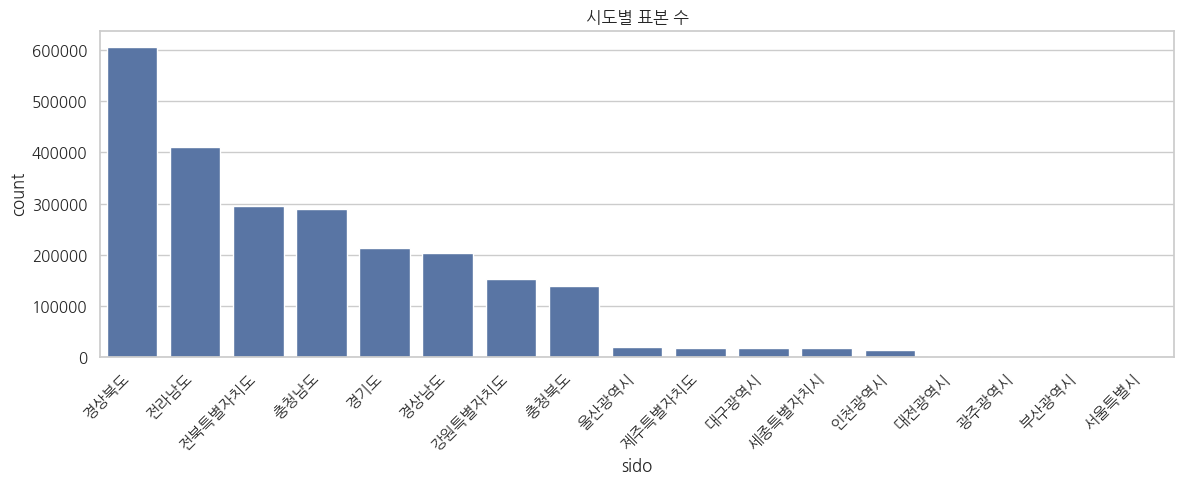

In [ ]:
plt.figure(figsize=(12, 5))

sido_counts = train["sido"].value_counts()

sns.barplot(
    x=sido_counts.index,
    y=sido_counts.values
)

plt.title("시도별 표본 수")
plt.xlabel("sido")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

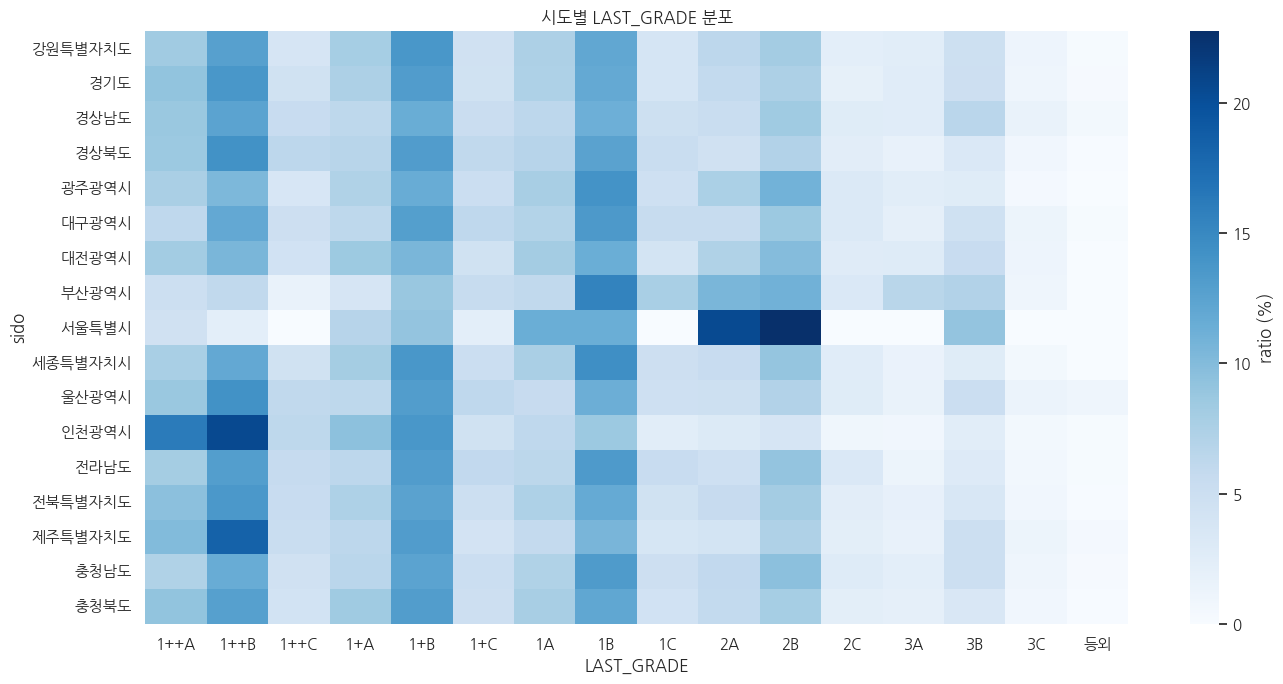

In [ ]:
sido_grade = pd.crosstab(
    train["sido"],
    train["LAST_GRADE"],
    normalize="index"
) * 100

plt.figure(figsize=(14, 7))

sns.heatmap(
    sido_grade,
    cmap="Blues",
    annot=False,
    cbar_kws={"label": "ratio (%)"}
)

plt.title("시도별 LAST_GRADE 분포")
plt.xlabel("LAST_GRADE")
plt.ylabel("sido")
plt.tight_layout()
plt.show()

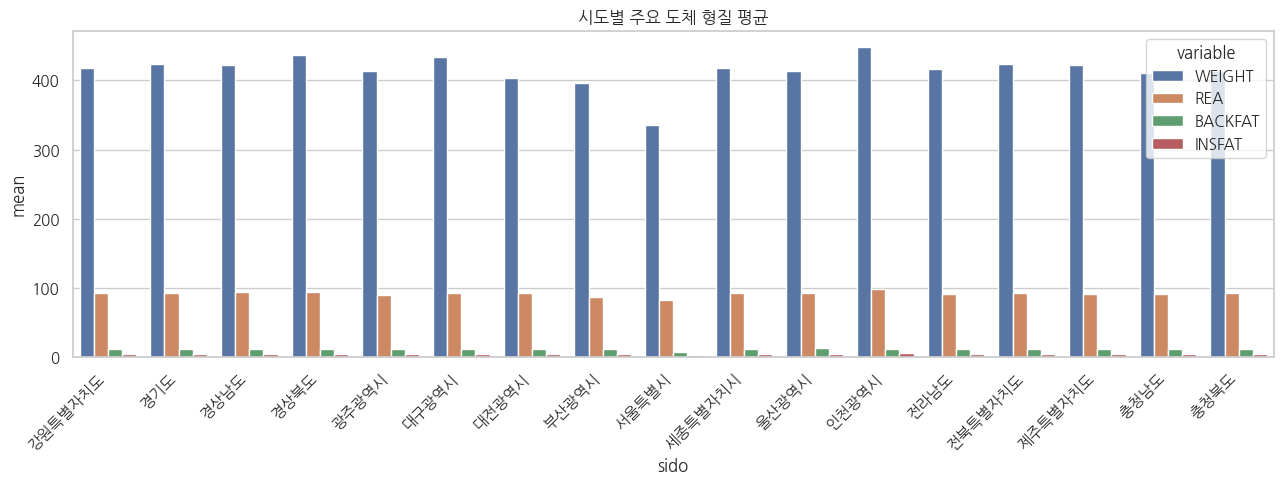

In [ ]:
region_mean = (
    train
    .groupby("sido")[["WEIGHT", "REA", "BACKFAT", "INSFAT"]]
    .mean()
    .reset_index()
    .melt(id_vars="sido", var_name="variable", value_name="mean")
)

plt.figure(figsize=(13, 5))

sns.barplot(
    data=region_mean,
    x="sido",
    y="mean",
    hue="variable"
)

plt.title("시도별 주요 도체 형질 평균")
plt.xlabel("sido")
plt.ylabel("mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

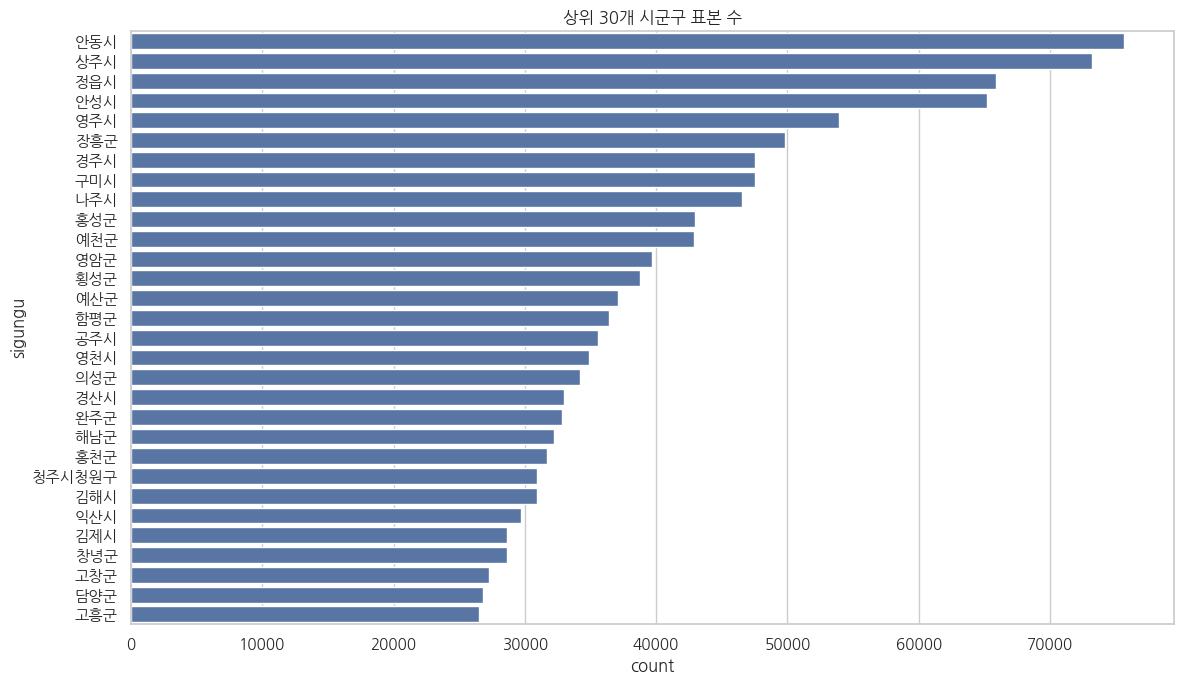

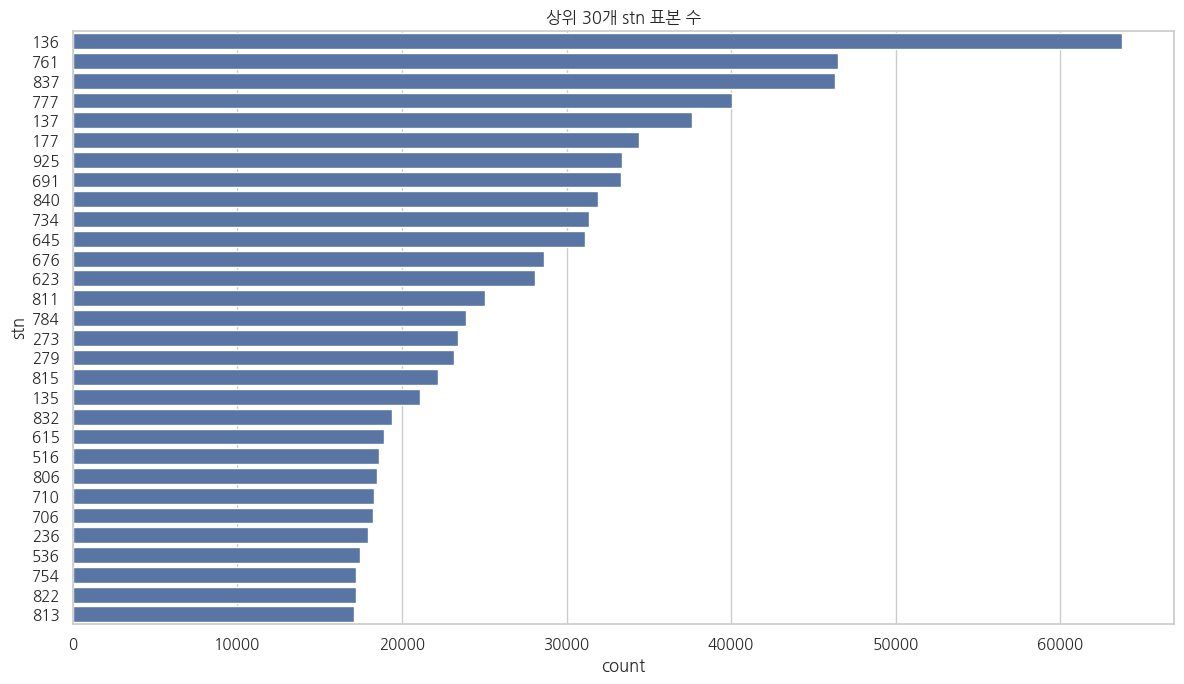

In [ ]:
top_sigungu = train["sigungu"].value_counts().head(30)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_sigungu.values,
    y=top_sigungu.index
)

plt.title("상위 30개 시군구 표본 수")
plt.xlabel("count")
plt.ylabel("sigungu")
plt.tight_layout()
plt.show()

top_stn = train["stn"].value_counts().head(30)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_stn.values,
    y=top_stn.index.astype(str)
)

plt.title("상위 30개 stn 표본 수")
plt.xlabel("count")
plt.ylabel("stn")
plt.tight_layout()
plt.show()

- 지역별 표본 수 불균형
- 지역별 등급 분포 차이
- 지역별 평균 체중/등심면적/근내지방도 차이
- 특정 지역이 데이터 대부분을 차지하는지

## 3-2. AREA 단독 EDA

In [ ]:
print(area[["C2023", "C2024", "C2025", "AREA"]].describe())
print("----------------")
print(area[["C2023", "C2024", "C2025", "AREA"]].isna().mean())
print("----------------")
print("중복된 행 갯수", area["FARM_UNIQUE_NO"].duplicated().sum())

            C2023       C2024       C2025        AREA
count 86,700.0000 80,912.0000 76,283.0000 62,853.0000
mean      39.6173     40.6312     41.4883    765.5186
std       60.2417     60.6687     61.7773    942.0875
min        1.0000      1.0000      1.0000      0.0000
25%        7.0000      7.0000      7.0000    223.6400
50%       21.0000     21.0000     22.0000    474.8400
75%       49.0000     50.0000     52.0000    996.0000
max    2,829.0000  2,765.0000  2,603.0000 48,360.0000
----------------
C2023   0.0565
C2024   0.1195
C2025   0.1699
AREA    0.3160
dtype: float64
----------------
중복된 행 갯수 5193


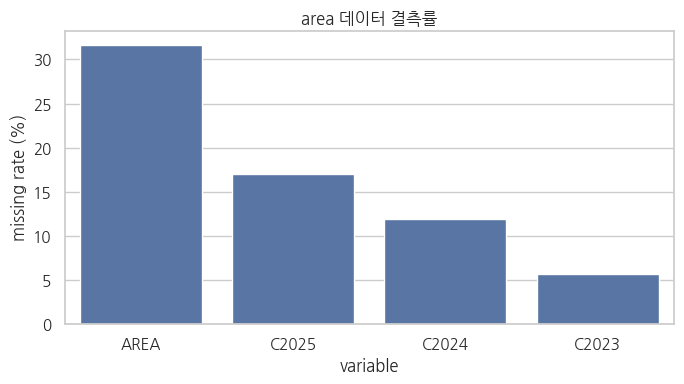

In [ ]:
area_cols = ["C2023", "C2024", "C2025", "AREA"]
area_cols = [c for c in area_cols if c in area.columns]

area_missing = area[area_cols].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 4))

sns.barplot(
    x=area_missing.index,
    y=area_missing.values
)

plt.title("area 데이터 결측률")
plt.xlabel("variable")
plt.ylabel("missing rate (%)")
plt.tight_layout()
plt.show()

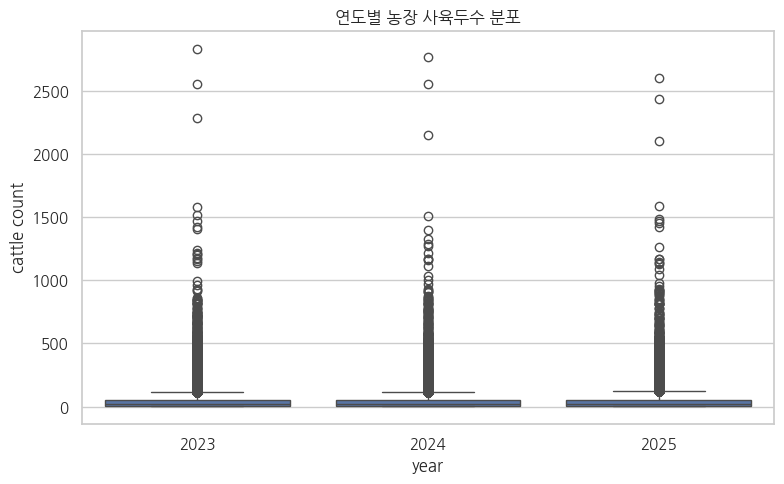

In [ ]:
area_long = area.melt(
    id_vars=["FARM_UNIQUE_NO", "AREA"],
    value_vars=["C2023", "C2024", "C2025"],
    var_name="year",
    value_name="cattle_count"
)

area_long["year"] = area_long["year"].str.extract(r"(\d{4})")

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=area_long,
    x="year",
    y="cattle_count"
)

plt.title("연도별 농장 사육두수 분포")
plt.xlabel("year")
plt.ylabel("cattle count")
plt.tight_layout()
plt.show()

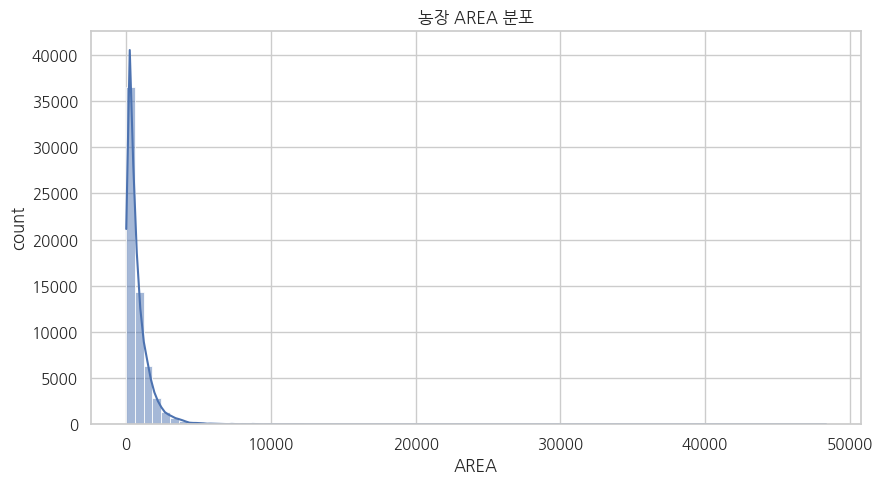

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    area["AREA"].dropna(),
    bins=80,
    kde=True
)

plt.title("농장 AREA 분포")
plt.xlabel("AREA")
plt.ylabel("count")
plt.tight_layout()
plt.show()

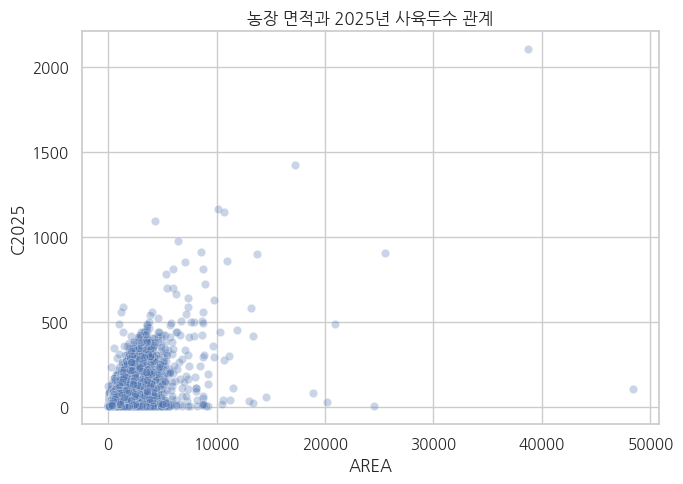

In [ ]:
area_plot = area.copy()
area_plot["cattle_count_2025"] = area_plot["C2025"]
area_plot["farm_density_2025"] = area_plot["cattle_count_2025"] / area_plot["AREA"]
area_plot = area_plot.replace([np.inf, -np.inf], np.nan)

area_plot_sample = area_plot.sample(
    n=min(50_000, len(area_plot)),
    random_state=42
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=area_plot_sample,
    x="AREA",
    y="cattle_count_2025",
    alpha=0.3
)

plt.title("농장 면적과 2025년 사육두수 관계")
plt.xlabel("AREA")
plt.ylabel("C2025")
plt.tight_layout()
plt.show()

- FARM_UNIQUE_NO가 유일한가
- C2023/C2024/C2025/AREA 결측률
- AREA 결측이 특정 농장 규모와 관련 있는가
- 사육두수와 면적의 극단값

## 3-3. death 단독 EDA

In [ ]:
death.shape

(321389, 4)

In [ ]:
death.duplicated().sum()

np.int64(8108)

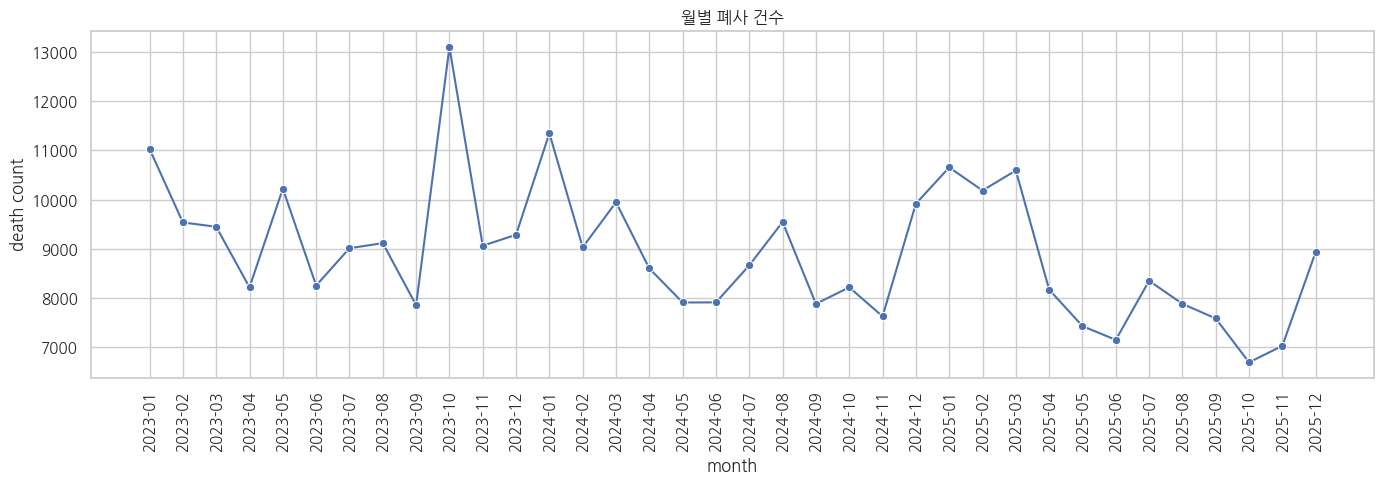

In [ ]:
death["dead_month"] = death["DEAD_YMD"].dt.to_period("M").astype(str)

death_month = (
    death
    .dropna(subset=["DEAD_YMD"])
    .groupby("dead_month")
    .size()
    .reset_index(name="death_count")
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=death_month,
    x="dead_month",
    y="death_count",
    marker="o"
)

plt.title("월별 폐사 건수")
plt.xlabel("month")
plt.ylabel("death count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

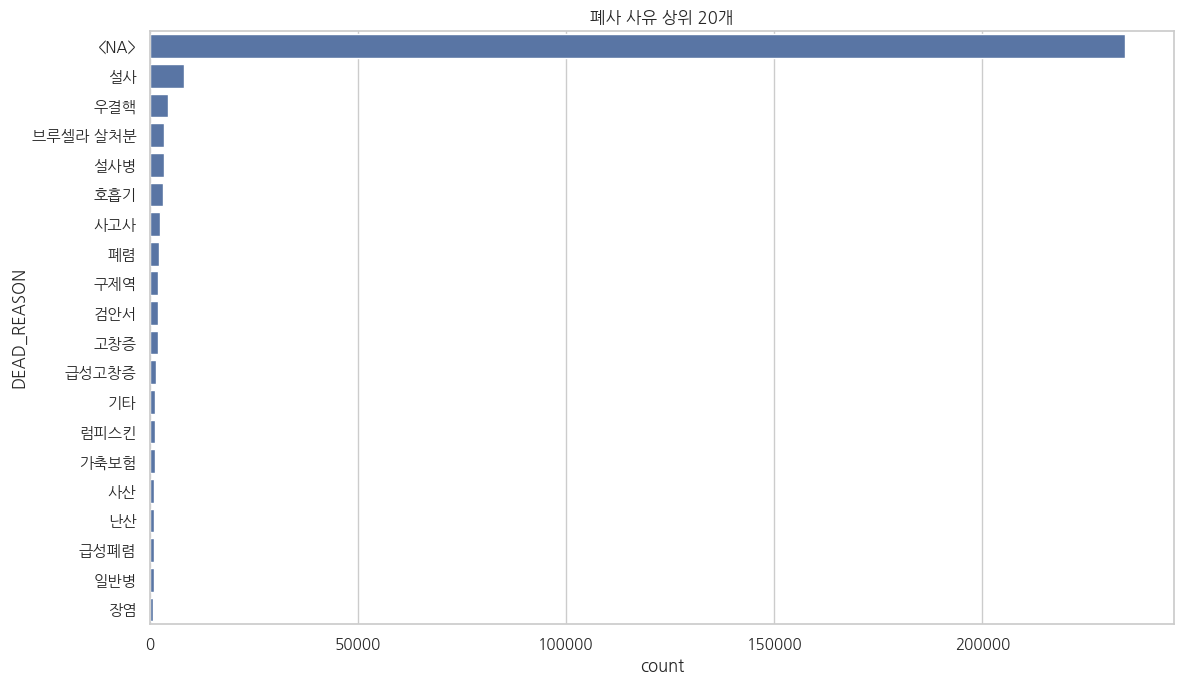

In [ ]:
death_reason_counts = death["DEAD_REASON"].value_counts(dropna=False).head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=death_reason_counts.values,
    y=death_reason_counts.index.astype(str)
)

plt.title("폐사 사유 상위 20개")
plt.xlabel("count")
plt.ylabel("DEAD_REASON")
plt.tight_layout()
plt.show()

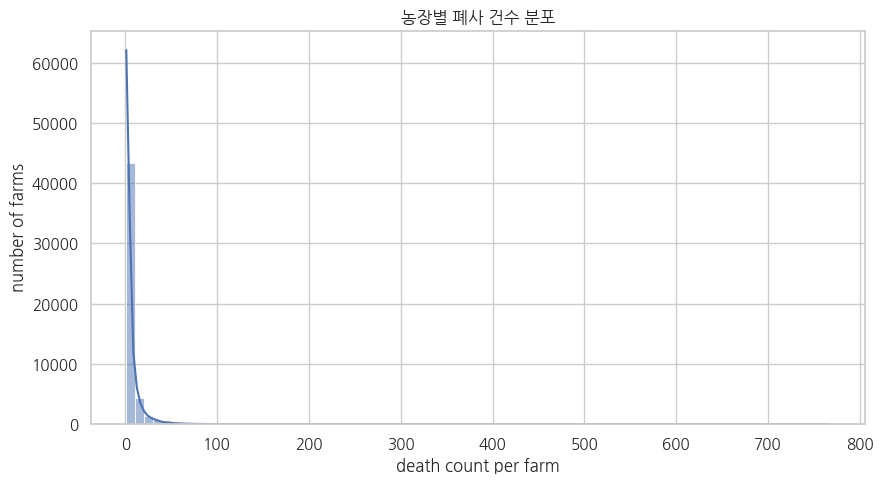

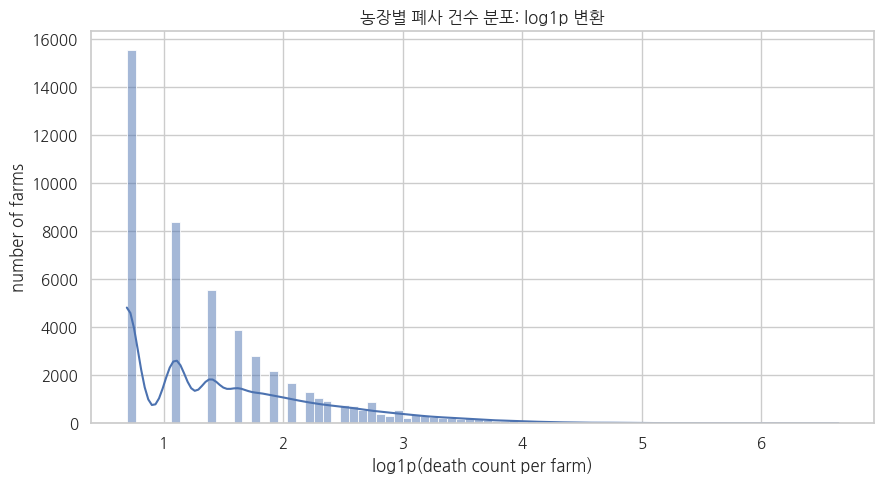

In [ ]:
farm_death_counts = death.groupby("FARM_UNIQUE_NO").size()

plt.figure(figsize=(9, 5))

sns.histplot(
    farm_death_counts,
    bins=80,
    kde=True
)

plt.title("농장별 폐사 건수 분포")
plt.xlabel("death count per farm")
plt.ylabel("number of farms")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))

sns.histplot(
    np.log1p(farm_death_counts),
    bins=80,
    kde=True
)

plt.title("농장별 폐사 건수 분포: log1p 변환")
plt.xlabel("log1p(death count per farm)")
plt.ylabel("number of farms")
plt.tight_layout()
plt.show()

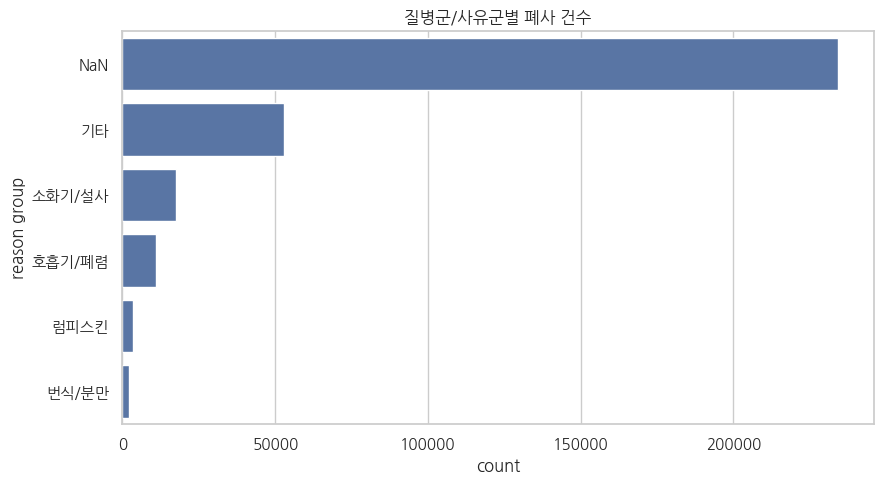

In [ ]:
def classify_death_reason(x):
    if pd.isna(x):
        return "NaN"

    x = str(x)

    if "폐렴" in x or "호흡" in x:
        return "호흡기/폐렴"
    elif "설사" in x or "장염" in x:
        return "소화기/설사"
    elif "럼피" in x:
        return "럼피스킨"
    elif "조산" in x or "난산" in x:
        return "번식/분만"
    elif x in ["-99", "-99.0"]:
        return "NaN"
    else:
        return "기타"

death["death_reason_group"] = death["DEAD_REASON"].apply(classify_death_reason)

reason_group_counts = death["death_reason_group"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=reason_group_counts.values,
    y=reason_group_counts.index
)

plt.title("질병군/사유군별 폐사 건수")
plt.xlabel("count")
plt.ylabel("reason group")
plt.tight_layout()
plt.show()

## 3-4. weather 단독 EDA

In [ ]:
weather.shape

(973248, 7)

In [ ]:
weather.duplicated(["stn", "date"]).sum()

np.int64(0)

In [ ]:
weather[["ta_max", "ta_min", "rn_day", "rhm_avg", "ws_davg"]].describe()

,ta_max,ta_min,rn_day,rhm_avg,ws_davg
count,"960,884.0000","960,884.0000","957,255.0000","925,093.0000","959,646.0000"
mean,19.0051,8.3456,3.8211,72.2384,1.8142
std,9.7753,10.6160,13.9844,15.1003,1.2024
min,-15.2000,-28.2000,0.0000,11.0000,0.1000
25%,11.1000,-0.3000,0.0000,62.3000,1.0000
50%,20.2000,8.3000,0.0000,74.6000,1.5000
75%,27.1000,17.9000,0.5000,83.8000,2.2000
max,43.4000,33.3000,438.9000,100.0000,22.3000


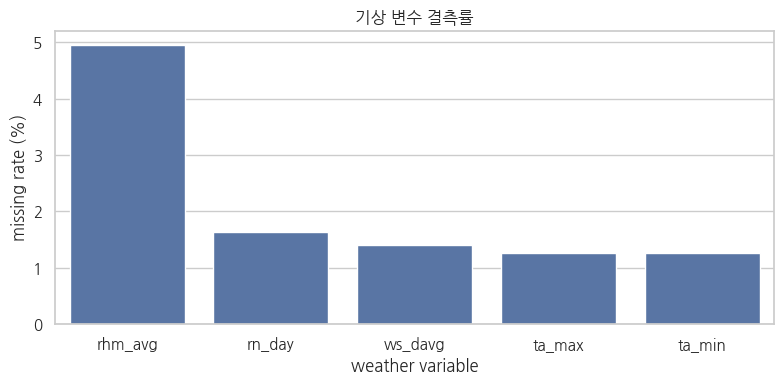

In [ ]:
weather_cols = ["ta_max", "rn_day", "ta_min", "rhm_avg", "ws_davg"]
weather_cols = [c for c in weather_cols if c in weather.columns]

weather_missing = weather[weather_cols].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 4))

sns.barplot(
    x=weather_missing.index,
    y=weather_missing.values
)

plt.title("기상 변수 결측률")
plt.xlabel("weather variable")
plt.ylabel("missing rate (%)")
plt.tight_layout()
plt.show()

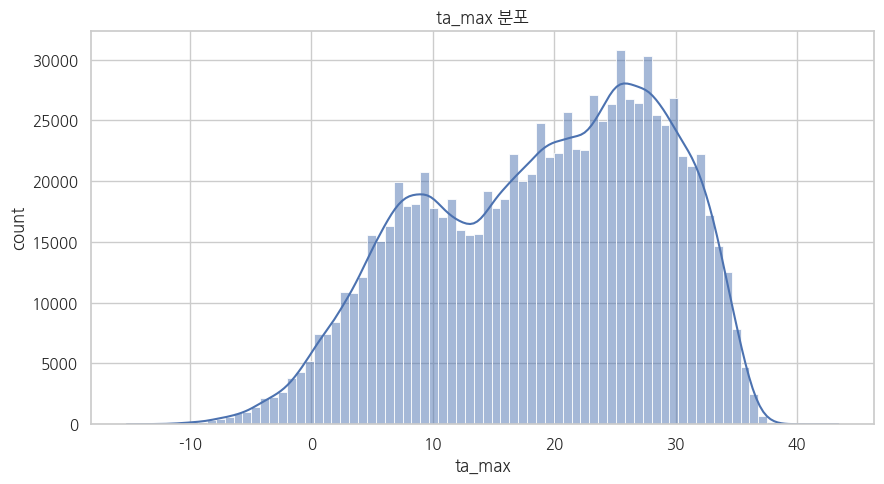

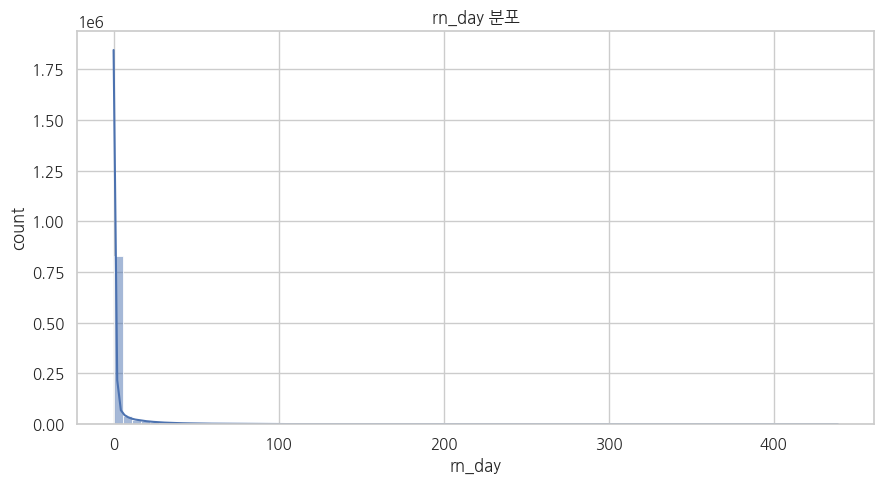

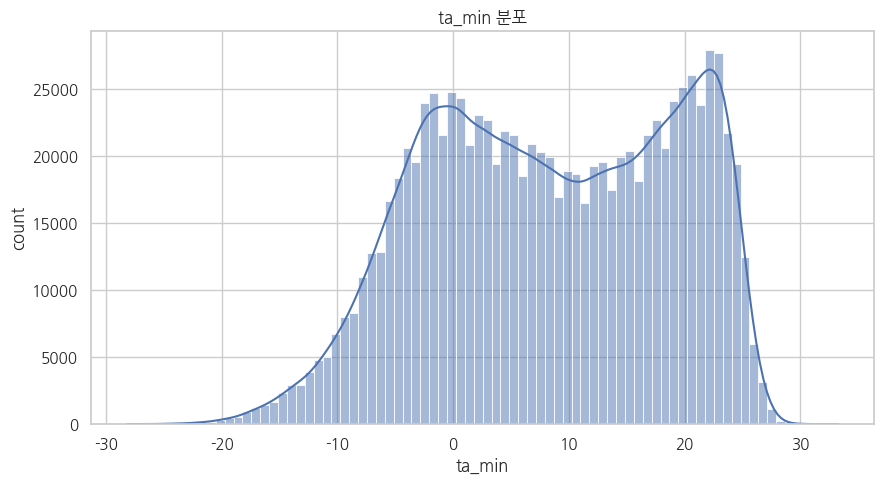

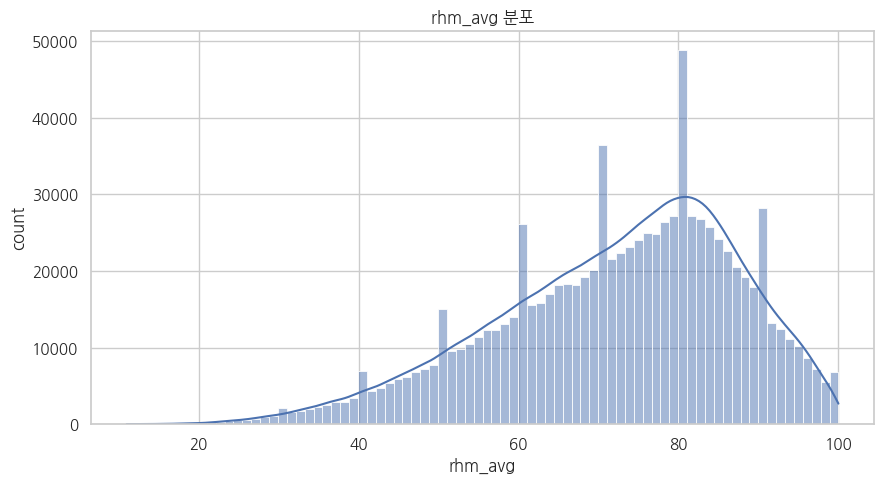

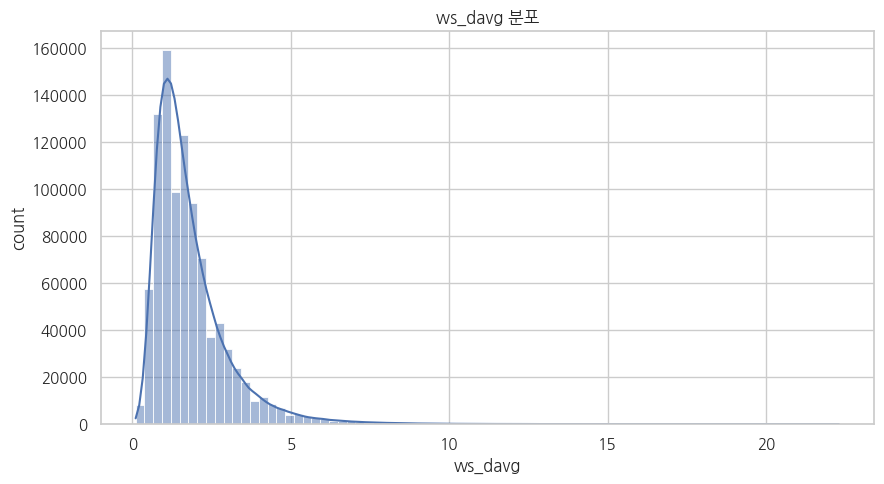

In [ ]:
for col in weather_cols:
    plt.figure(figsize=(9, 5))

    sns.histplot(
        weather[col].dropna(),
        bins=80,
        kde=True
    )

    plt.title(f"{col} 분포")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

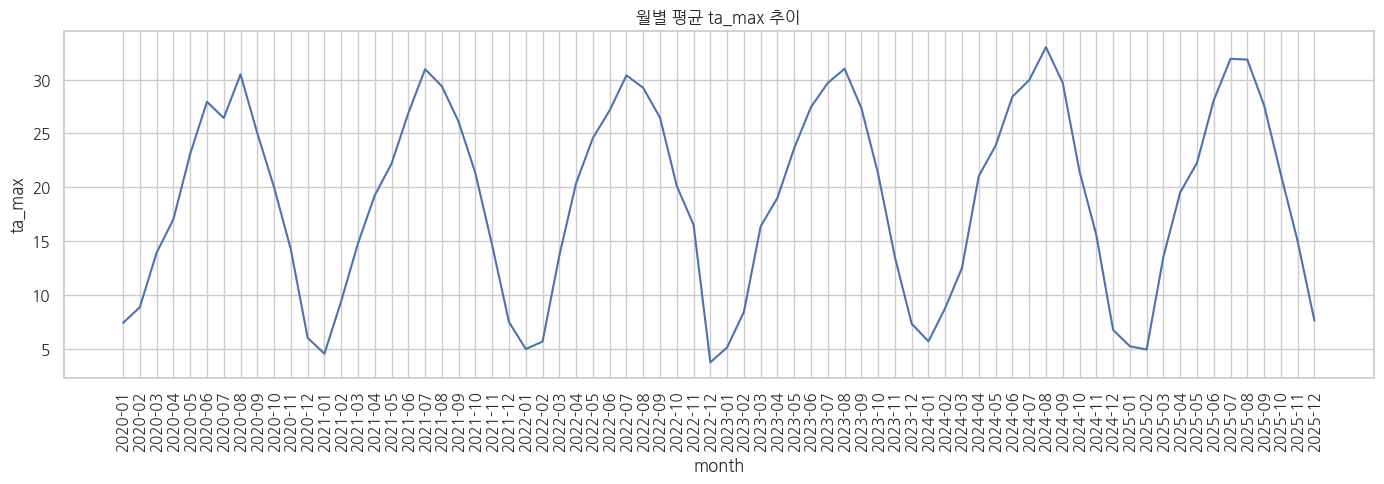

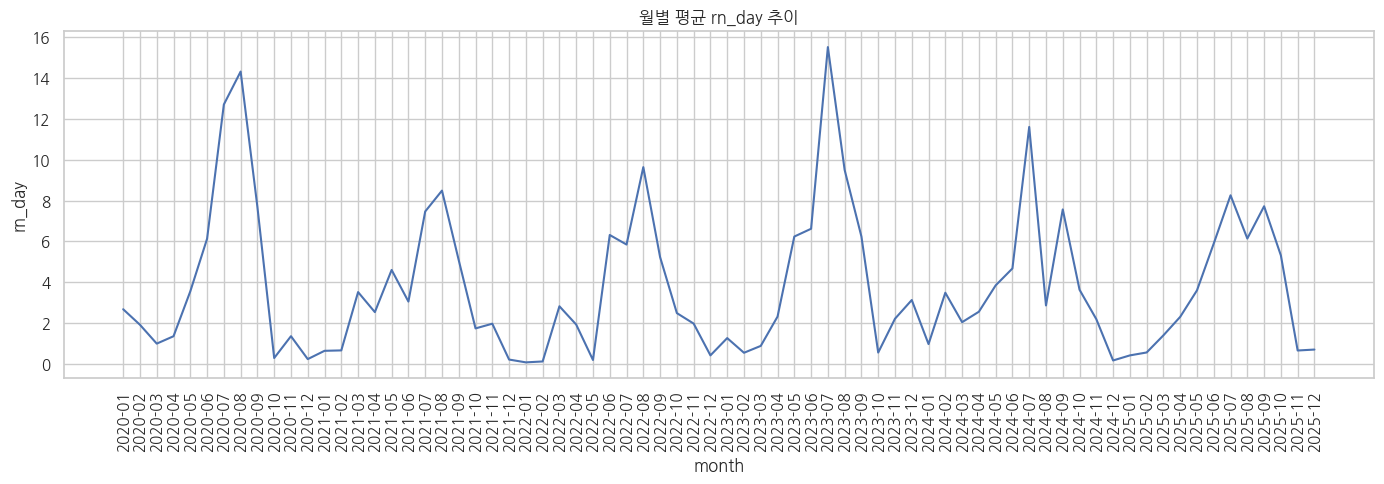

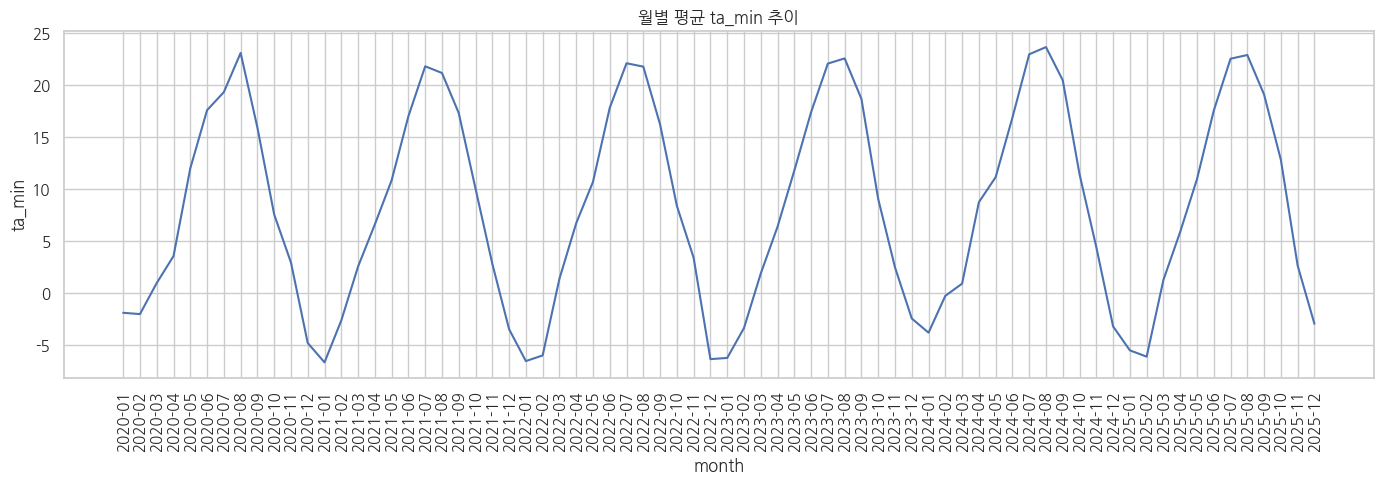

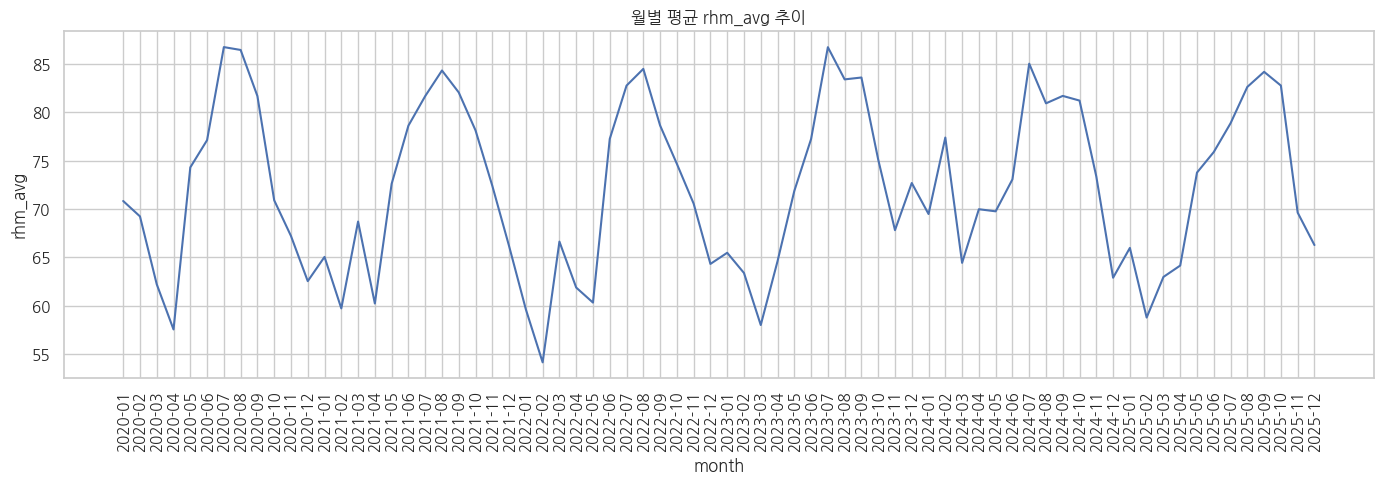

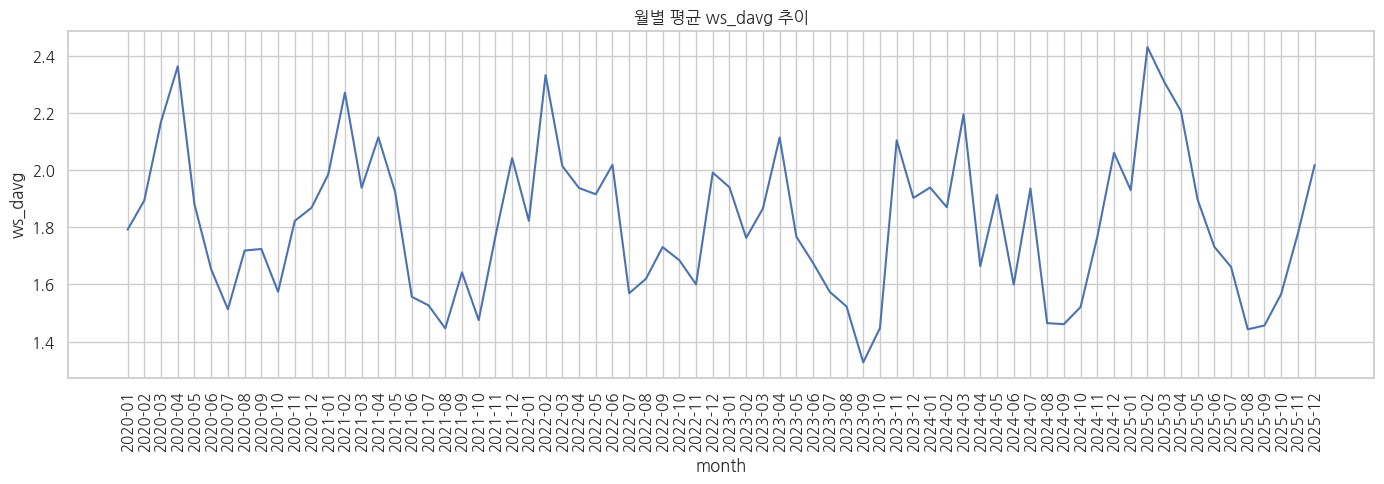

In [ ]:
weather["year_month"] = weather["date"].dt.to_period("M").astype(str)

weather_month = (
    weather
    .groupby("year_month")[weather_cols]
    .mean()
    .reset_index()
)

for col in weather_cols:
    plt.figure(figsize=(14, 5))

    sns.lineplot(
        data=weather_month,
        x="year_month",
        y=col
    )

    plt.title(f"월별 평균 {col} 추이")
    plt.xlabel("month")
    plt.ylabel(col)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

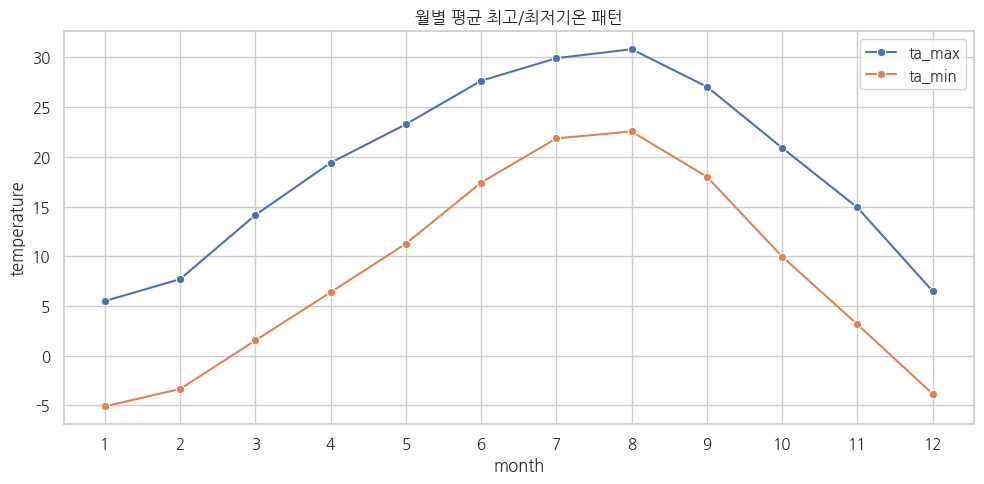

In [ ]:
weather["month"] = weather["date"].dt.month

weather_monthly_pattern = (
    weather
    .groupby("month")[["ta_max", "ta_min", "rhm_avg", "ws_davg", "rn_day"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(data=weather_monthly_pattern, x="month", y="ta_max", marker="o", label="ta_max")
sns.lineplot(data=weather_monthly_pattern, x="month", y="ta_min", marker="o", label="ta_min")

plt.title("월별 평균 최고/최저기온 패턴")
plt.xlabel("month")
plt.ylabel("temperature")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

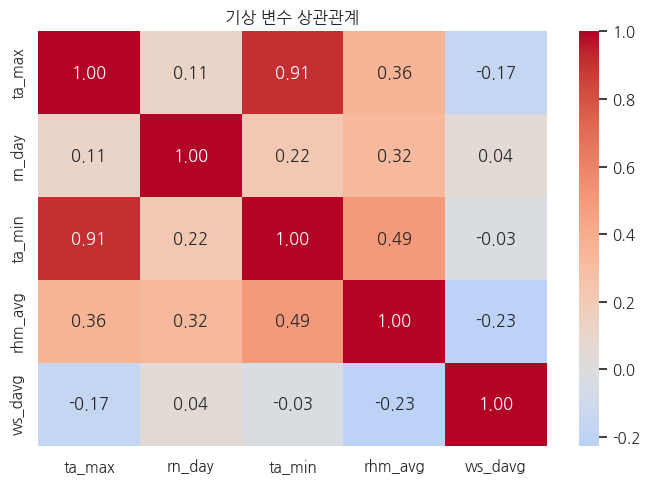

In [ ]:
plt.figure(figsize=(7, 5))

weather_corr = weather[weather_cols].corr()

sns.heatmap(
    weather_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("기상 변수 상관관계")
plt.tight_layout()
plt.show()

## 3-5. lineage 단독 EDA

In [ ]:
lineage["CATTLE_NO"].duplicated().sum()

np.int64(0)

In [ ]:
coverage = train["CATTLE_NO"].isin(lineage["CATTLE_NO"]).mean()
coverage

np.float64(0.6169496479219695)

coverage가 약 61.7%라면 혈통 정보가 없는 개체가 꽤 많다는 뜻

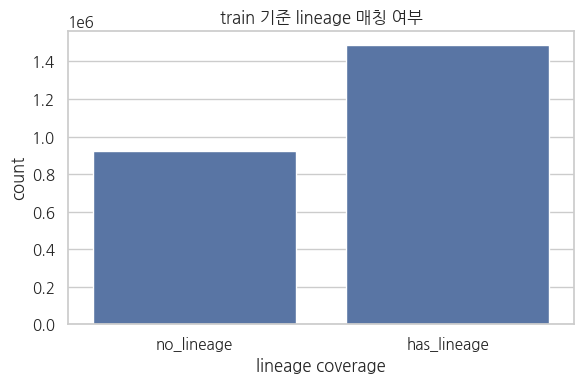

In [ ]:
train["has_lineage"] = train["CATTLE_NO"].isin(lineage["CATTLE_NO"]).astype(int)

coverage_counts = train["has_lineage"].value_counts().sort_index()
coverage_counts.index = ["no_lineage", "has_lineage"]

plt.figure(figsize=(6, 4))

sns.barplot(
    x=coverage_counts.index,
    y=coverage_counts.values
)

plt.title("train 기준 lineage 매칭 여부")
plt.xlabel("lineage coverage")
plt.ylabel("count")
plt.tight_layout()
plt.show()

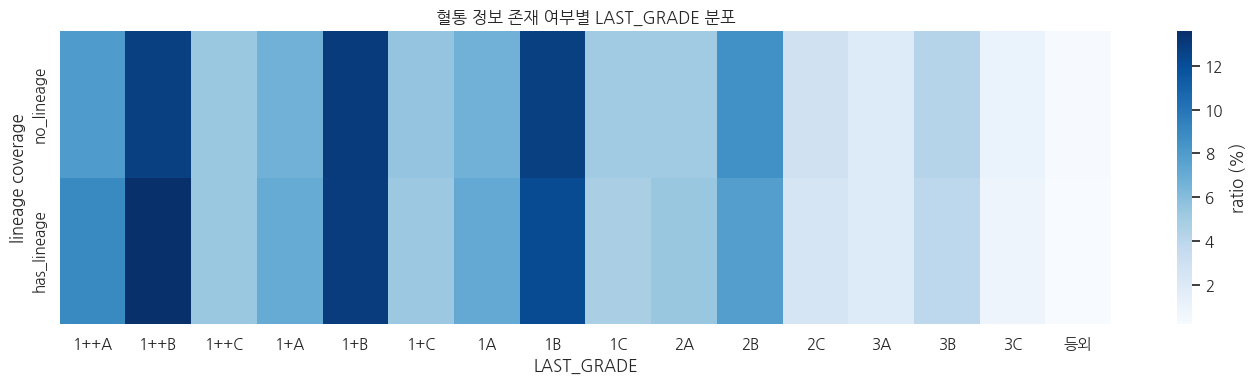

In [ ]:
lineage_grade = pd.crosstab(
    train["has_lineage"],
    train["LAST_GRADE"],
    normalize="index"
) * 100

lineage_grade.index = ["no_lineage", "has_lineage"]

plt.figure(figsize=(14, 4))

sns.heatmap(
    lineage_grade,
    cmap="Blues",
    annot=False,
    cbar_kws={"label": "ratio (%)"}
)

plt.title("혈통 정보 존재 여부별 LAST_GRADE 분포")
plt.xlabel("LAST_GRADE")
plt.ylabel("lineage coverage")
plt.tight_layout()
plt.show()

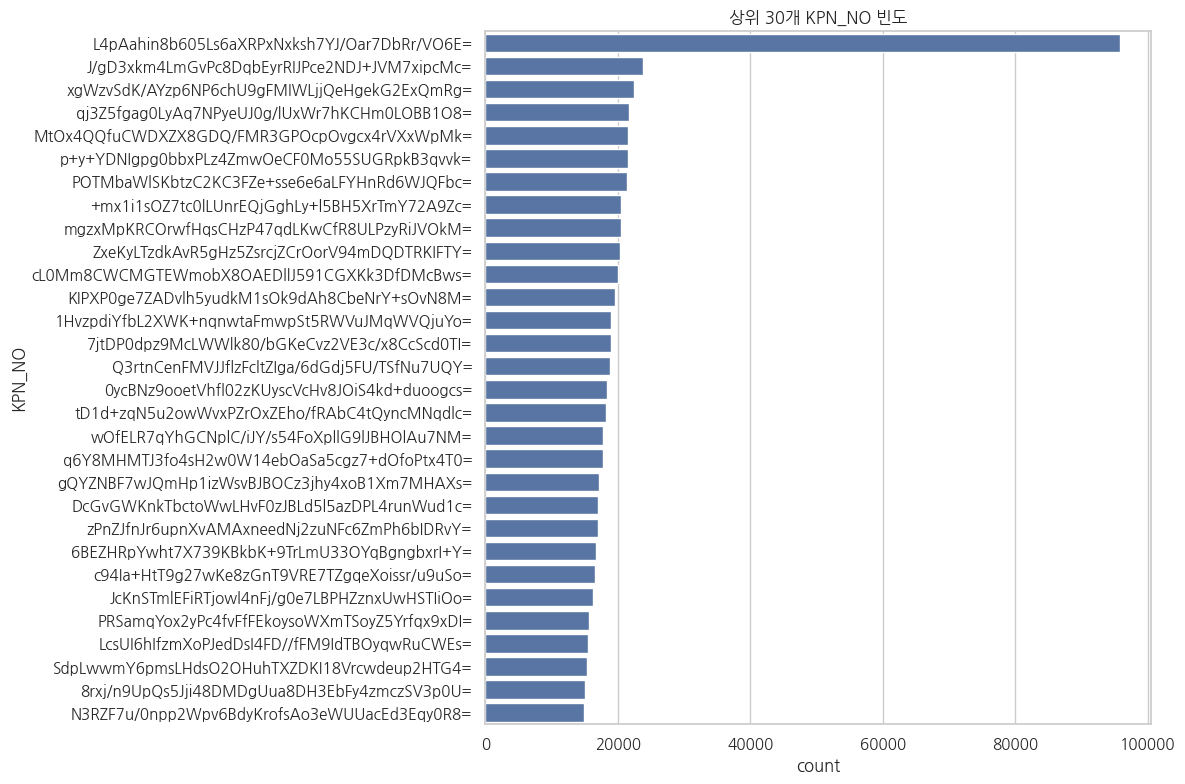

In [ ]:
top_kpn = lineage["KPN_NO"].value_counts(dropna=False).head(30)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_kpn.values,
    y=top_kpn.index.astype(str)
)

plt.title("상위 30개 KPN_NO 빈도")
plt.xlabel("count")
plt.ylabel("KPN_NO")
plt.tight_layout()
plt.show()

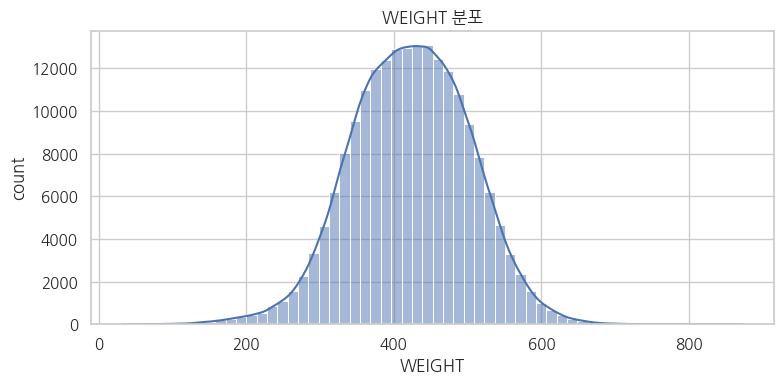

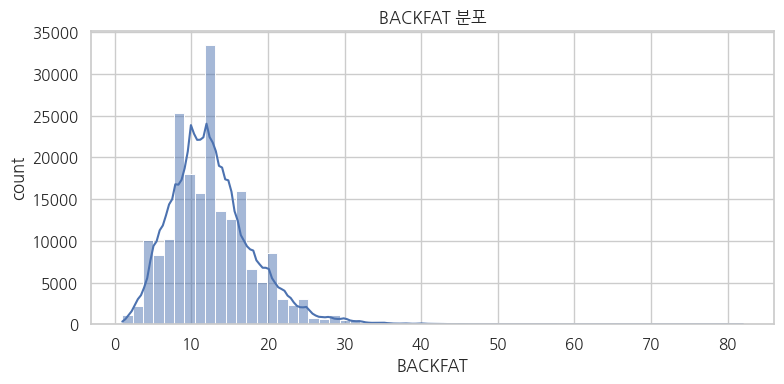

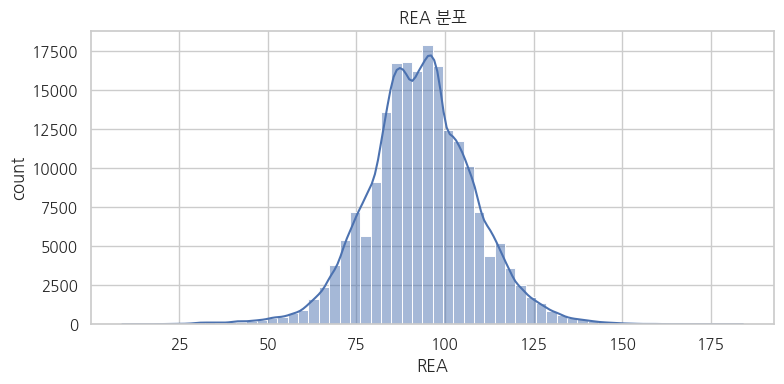

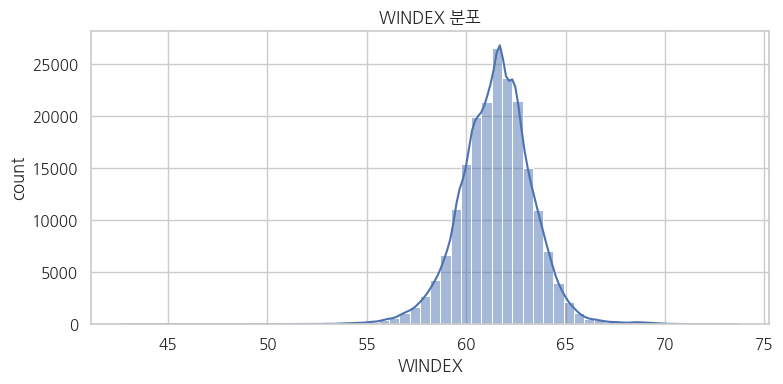

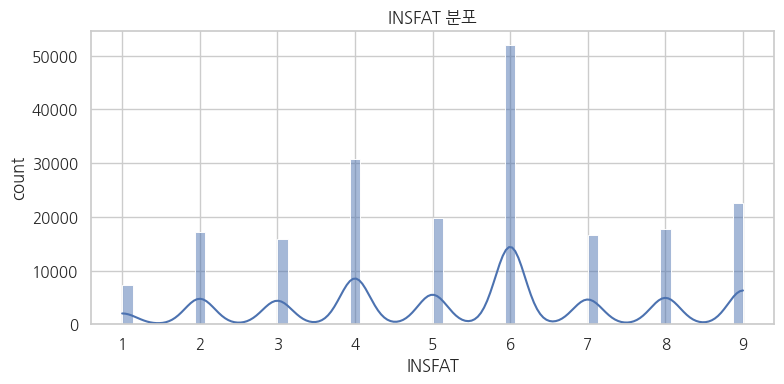

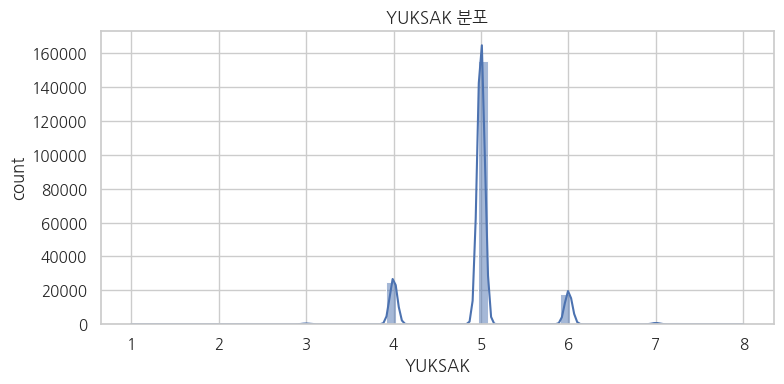

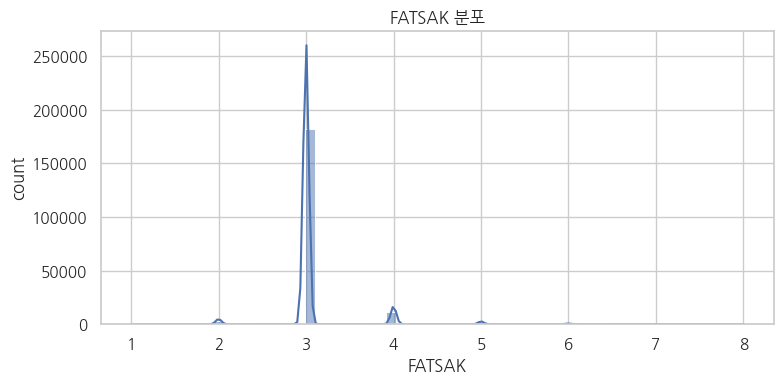

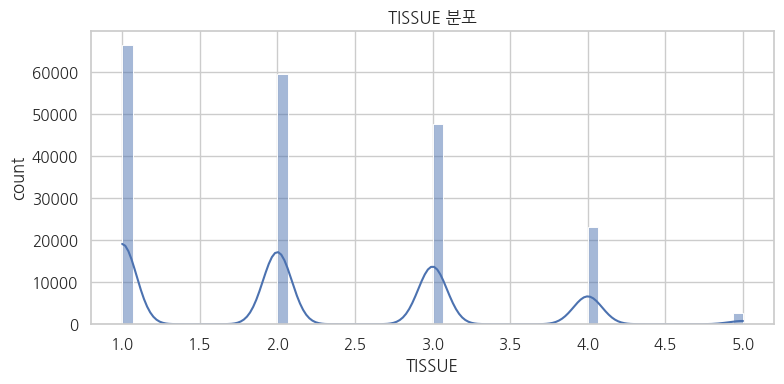

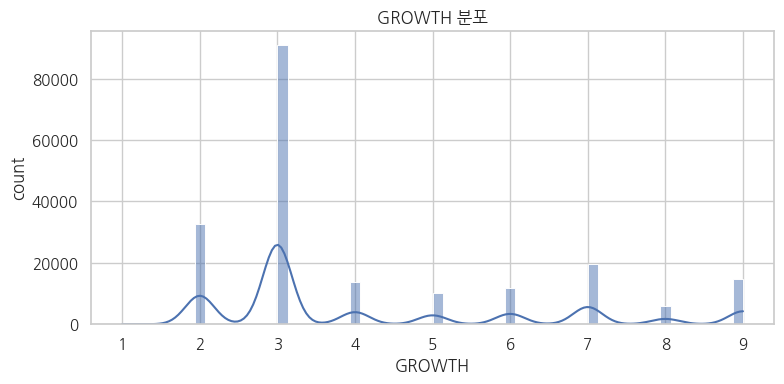

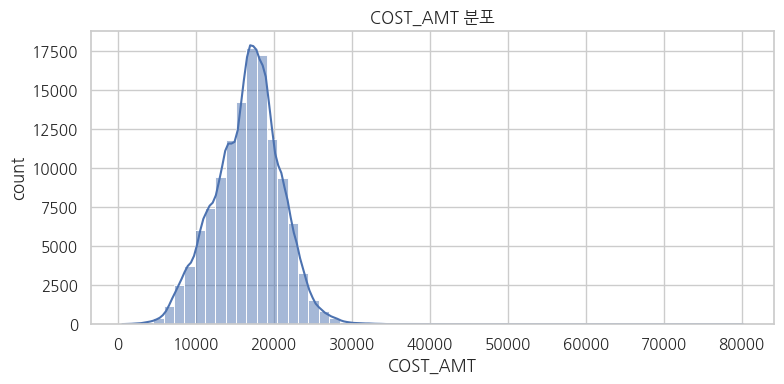

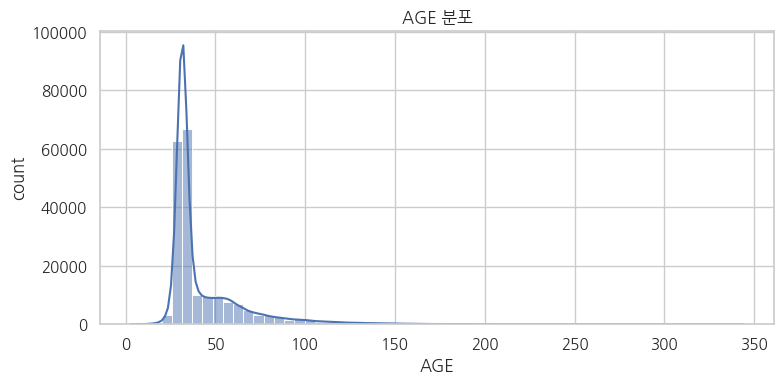

In [ ]:
main_numeric_cols = [
    "WEIGHT", "BACKFAT", "REA", "WINDEX",
    "INSFAT", "YUKSAK", "FATSAK", "TISSUE",
    "GROWTH", "COST_AMT", "AGE"
]

main_numeric_cols = [c for c in main_numeric_cols if c in train.columns]

for col in main_numeric_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        train_sample[col].dropna(),
        bins=60,
        kde=True
    )

    plt.title(f"{col} 분포")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()